# **US Super Store Sales Analysis**

## **Introduction**

**The data spans a robust four-year period from 2011 to 2015 . This dataset contains sales, profit, shipping and geographical information, categories and sub-categories of sold products across 147 countries.**

Brief description of columns:

- **Order Information**

    - **Order ID** – Unique identifier for each order.

    - **Order Date** – Date when the order was placed.

    - **Ship Date** – Date when the order was shipped.

    - **Ship Mode** – Shipping method (e.g., Standard Class, Second Class, First Class, Same Day).

- **Customer Information**

    - **Customer ID** – Unique identifier for each customer.

    - **Customer Name** – Name of the customer.

    - **Segment** – Customer segment (Consumer, Corporate, Home Office).

    - **Country** – Country where the customer is located.

    - **City / State / Region** – Geographic details of the customer.

- **Product Information**

    - **Product ID** – Unique identifier for each product.

    - **Category** – Broad product category (Furniture, Office Supplies, Technology).

    - **Sub-Category** – More specific product type (e.g., Chairs, Phones, Binders).

    - **Product Name** – Name/description of the product.

- **Sales & Profit Metrics**

    - **Sales** – Revenue generated from the order.

    - **Quantity** – Number of units sold.

    - **Discount** – Discount applied to the order.

    - **Profit** – Profit earned from the order after costs.

- **Geographic & Managerial**

    - **Region** – Region of the world (e.g., Asia, Europe, US).

    - **Postal Code** – Postal/ZIP code of the customer.

    - **Market** – Market grouping (e.g., APAC, EMEA).

- **Returns (separate sheet)**

    - **Returned** – Indicates whether an order was returned.

## **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
import sklearn
from scipy import stats
import kaggle
from pathlib import Path
import sidetable

## **Display Settings**

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_info_rows', 1000)
import warnings
warnings.filterwarnings('ignore')

## **Data Ingestion & Exploration**

In [3]:
path = Path.cwd()
paths = path.parent.joinpath('data', 'raw')

file = []
for p in paths.glob('*'):
    file.append(p.name)

print(file)

['.gitkeep', 'Global Superstore.xls']


In [4]:
#find all excel files name in .xls sheet
df = pd.read_excel(paths/'Global Superstore.xls',sheet_name=None)
df.keys()

dict_keys(['Orders', 'Returns', 'People'])

In [5]:
orders = pd.read_excel(paths/'Global Superstore.xls',sheet_name='Orders')
return_df = pd.read_excel(paths/'Global Superstore.xls',sheet_name='Returns')
people_df = pd.read_excel(paths/'Global Superstore.xls',sheet_name='People')
display(orders.tail(1),
    return_df.tail(1),
    people_df.tail(1))

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,Country,Postal Code,Market,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
51289,6147,MX-2012-134460,2012-05-22,2012-05-26,Second Class,MC-18100,Mick Crebagga,Consumer,Tipitapa,Managua,Nicaragua,NaN,LATAM,Central,OFF-PA-10004155,Office Supplies,Paper,"Eaton Computer Printout Paper, 8.5 x 11",61.38,3,0.0,1.8,0.002,High


,Returned,Order ID,Market
1172,Yes,CA-2014-168193,United States


,Person,Region
12,Alejandro Ballentine,Southeast Asia


In [6]:
order_df = orders.copy()
display('Orders shape :',order_df.shape, 
        'Returns shape', return_df.shape, 
        'People shape',people_df.shape)

'Orders shape :'

(51290, 24)

'Returns shape'

(1173, 3)

'People shape'

(13, 2)

In [7]:
# remove whitespaces from column names and lower case of all columns
dfs = [order_df, return_df, people_df]
for df in dfs:
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")


In [8]:
order_df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   row_id          51290 non-null  int64         
 1   order_id        51290 non-null  object        
 2   order_date      51290 non-null  datetime64[ns]
 3   ship_date       51290 non-null  datetime64[ns]
 4   ship_mode       51290 non-null  object        
 5   customer_id     51290 non-null  object        
 6   customer_name   51290 non-null  object        
 7   segment         51290 non-null  object        
 8   city            51290 non-null  object        
 9   state           51290 non-null  object        
 10  country         51290 non-null  object        
 11  postal_code     9994 non-null   float64       
 12  market          51290 non-null  object        
 13  region          51290 non-null  object        
 14  product_id      51290 non-null  object        
 15  ca

In [9]:
return_df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1173 entries, 0 to 1172
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   returned  1173 non-null   object
 1   order_id  1173 non-null   object
 2   market    1173 non-null   object
dtypes: object(3)
memory usage: 27.6+ KB


In [10]:
dtype_df = pd.DataFrame({
    'dtype': order_df.dtypes,
    'nunique': order_df.nunique(),
    'unique' : [order_df[col].unique() for col in order_df.columns]
}, index=order_df.columns)
display(dtype_df)

,dtype,nunique,unique
row_id,int64,51290,"[32298, 26341, 25330, 13524, 47221, 22732, 305..."
order_id,object,25035,"[CA-2012-124891, IN-2013-77878, IN-2013-71249,..."
order_date,datetime64[ns],1430,"[2012-07-31 00:00:00, 2013-02-05 00:00:00, 201..."
ship_date,datetime64[ns],1464,"[2012-07-31 00:00:00, 2013-02-07 00:00:00, 201..."
ship_mode,object,4,"[Same Day, Second Class, First Class, Standard..."
customer_id,object,1590,"[RH-19495, JR-16210, CR-12730, KM-16375, RH-94..."
customer_name,object,795,"[Rick Hansen, Justin Ritter, Craig Reiter, Kat..."
segment,object,3,"[Consumer, Corporate, Home Office]"
city,object,3636,"[New York City, Wollongong, Brisbane, Berlin, ..."
state,object,1094,"[New York, New South Wales, Queensland, Berlin..."


**Check whether the object columns contains invalid UTF-8 entries?**

In [11]:
def find_invalid_utf8(df):
    """
    Identify string columns in a DataFrame that contain invalid UTF-8 entries.
    
    Parameters:
        df (pd.DataFrame): Input DataFrame
    
    Returns:
        dict: {column_name: invalid_count} for columns with >0 invalid entries
    """
    # Select only object (string) columns
    string_cols = df.select_dtypes(include=['object'])
    
    # Helper function to check UTF-8 validity
    def is_valid_utf8(value):
        try:
            if isinstance(value, str):
                value.encode('utf-8')
            return True
        except UnicodeEncodeError:
            return False
    
    # Count invalid entries per column
    invalid_counts = {}
    for col in string_cols.columns:
        count = (~string_cols[col].apply(is_valid_utf8)).sum()
        if count > 0:
            invalid_counts[col] = count
    
    return invalid_counts

# Apply for orders and returns data
orders_invalid_cols = find_invalid_utf8(order_df)
returns_invalid_cols = find_invalid_utf8(return_df)
person_invalid_cols = find_invalid_utf8(people_df)
print(orders_invalid_cols); print(returns_invalid_cols); print(person_invalid_cols)

{}
{}
{}


## **Missing Value Analysis**

In [12]:
missing_df = order_df.stb.missing()
missing_df[missing_df['percent']>0]

,missing,total,percent
postal_code,41296,51290,80.51472


In [13]:
return_df.stb.missing()

,missing,total,percent
returned,0,1173,0.0
order_id,0,1173,0.0
market,0,1173,0.0


- **order_df has only ~81% missing values in postal code column. We can impute it with mode or drop it as well since it is not a key column for analysis.**

- **return_df has no missing values.**

- **raw_id column has all distinct values which of no use drop it.**

In [14]:
order_df.duplicated().sum()

0

## **Duplicate Data**

In [15]:
data = {'order' : order_df, 'returns' : return_df, 'people' : people_df}
for name, dfs in data.items():
    dup_count = dfs.duplicated().sum()
    print(f"Duplicate Data in {name} data = {dup_count}")

Duplicate Data in order data = 0
Duplicate Data in returns data = 0
Duplicate Data in people data = 0


### **Merged Orders and Returns Data for Analysis**

In [16]:
from sympy import intersection


(order_df.columns).intersection(return_df.columns)

Index(['order_id', 'market'], dtype='object')

In [17]:
print(f"Market in order data: {set(order_df['market'])}")
print(f"Market in return data: {set(return_df['market'])}")
print(f"Market in order data not in return: {(set(order_df['market'])).difference(set(return_df['market']))}")
print(f"Market in return data not in order: {(set(return_df['market'])).difference(set(order_df['market']))}")
print((set(order_df['market'])).difference(set(return_df['market'])))

Market in order data: {'Africa', 'EU', 'EMEA', 'Canada', 'US', 'APAC', 'LATAM'}
Market in return data: {'United States', 'LATAM', 'APAC', 'EU'}
Market in order data not in return: {'Africa', 'US', 'EMEA', 'Canada'}
Market in return data not in order: {'United States'}
{'Africa', 'US', 'EMEA', 'Canada'}


In [18]:
def clean_return_df(raw_df):
    clean_df = raw_df.copy()
    # transform return column to bool type
    clean_df['returned'] = clean_df['returned'].map({'Yes': True, 'No': False})
    # since order has 'US' market only but returns has 'Unites States' market name, we will change 'United States' to 'US'
    clean_df['market'].replace({'United States': 'US'}, inplace=True)
    return clean_df

# clean returns data
returned_df = clean_return_df(return_df)

In [19]:
# Complete order-returns data for furthur analysis
merged_df = pd.merge(order_df, returned_df, on =['order_id', 'market'], how='left')
# merged_df basic information
print(f"Merged data shape: {merged_df.shape}", '\n')
# Duplicate entries and missing values
print(f"Merged data duplicate data: {merged_df.duplicated().sum()}",'\n')
miss_df = merged_df.stb.missing()
miss_df = miss_df.query("percent > 0")
print(f"Missing data in merged data:\n {miss_df}")

Merged data shape: (51290, 25) 

Merged data duplicate data: 0 

Missing data in merged data:
              missing  total   percent
returned       48247  51290  94.06707
postal_code    41296  51290  80.51472


In [20]:
# Replace returned missing values with False bcoz they are non-returned orders and postal_code will be dropped if it's redundant.
# About returned column
print(f"Data of 'returned' column type : {merged_df['returned'].dtype}",'\n')
print(f"Data counts of 'returned' column :\n{merged_df['returned'].value_counts(dropna=False)}")


Data of 'returned' column type : object 

Data counts of 'returned' column :
returned
NaN     48247
True     3043
Name: count, dtype: int64


In [21]:
merged_df['returned'] = merged_df['returned'].fillna(False)
merged_df['returned'].value_counts()

returned
False    48247
True      3043
Name: count, dtype: int64

### **Descriptive Statistics**

**Categorical Variables**

In [22]:
merged_df.describe(exclude='number')

,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,city,state,country,market,region,product_id,category,sub-category,product_name,order_priority,returned
count,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290
unique,25035,NaN,NaN,4,1590,795,3,3636,1094,147,7,13,10292,3,17,3788,4,2
top,CA-2014-100111,NaN,NaN,Standard Class,PO-18850,Muhammed Yedwab,Consumer,New York City,California,United States,APAC,Central,OFF-AR-10003651,Office Supplies,Binders,Staples,Medium,False
freq,14,NaN,NaN,30775,97,108,26518,915,2001,9994,11002,11117,35,31273,6152,227,29433,48247
mean,NaN,2013-05-11 21:26:49.155781120,2013-05-15 20:42:42.745174528,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,2011-01-01 00:00:00,2011-01-03 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,2012-06-19 00:00:00,2012-06-23 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,2013-07-08 00:00:00,2013-07-12 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,2014-05-22 00:00:00,2014-05-26 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,2014-12-31 00:00:00,2015-01-07 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
# Doing US Super Store Sales Analysis 
us_merged_df = merged_df.query("country == 'United States'")

In [24]:
np.sort(us_merged_df['country'].unique())

array(['United States'], dtype=object)

## **Univariate Visualization**

### **Categorical Variables**

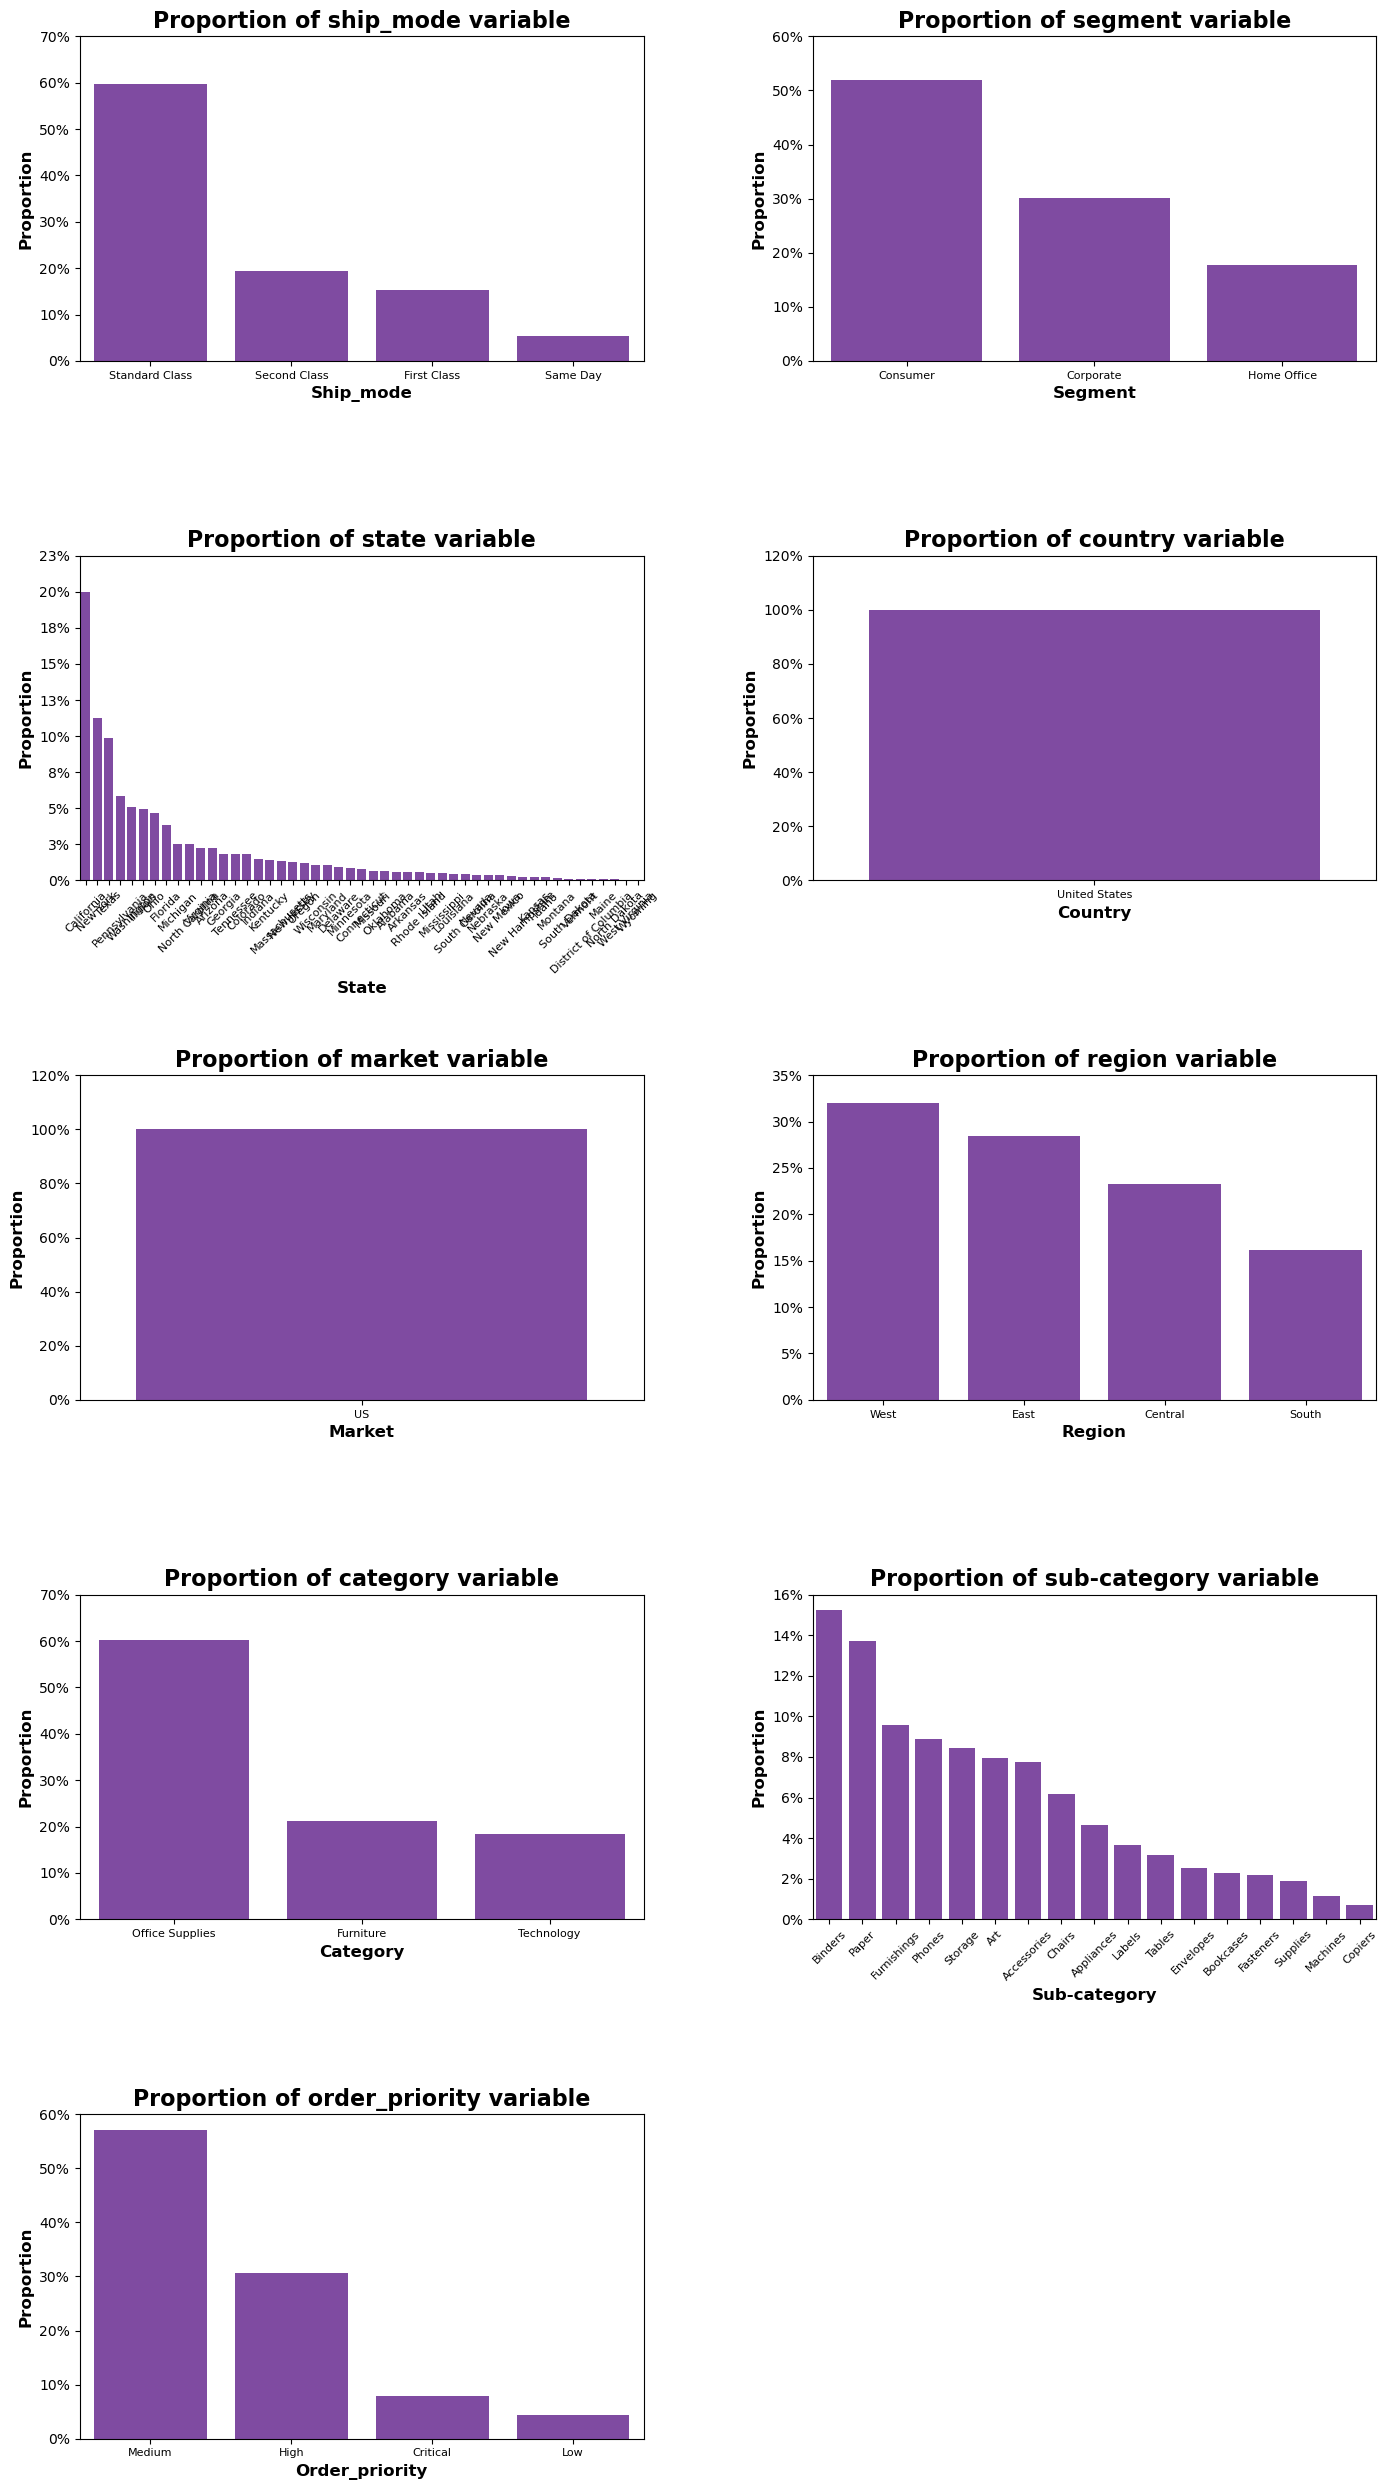

In [25]:
import math
# Select categorical columns except specified ones
all_column = us_merged_df.select_dtypes(include=['category', 'object']).drop(
    columns=['city','order_id', 'customer_id', 'customer_name', 'product_id', 'product_name'],
    errors='ignore'
)

# Dynamically calculate grid size
n_cols = 2   # fix 2 columns
n_rows = math.ceil(len(all_column.columns) / n_cols)

fig, ax = plt.subplots(n_rows, n_cols, figsize=(14, 5*n_rows))
ax = ax.flatten()

for i, col in enumerate(all_column.columns):
    sns.countplot(
        data=all_column,
        x=col,
        order=all_column[col].value_counts().index,
        color='#823DAF',
        ax=ax[i]
    )

    # Format y-axis as proportions
    total = len(all_column[col])
    ax[i].set_yticks(ax[i].get_yticks())
    ax[i].set_yticklabels([f"{val/total:.0%}" for val in ax[i].get_yticks()])

    # Labels and titles
    ax[i].set_xlabel(col.capitalize(), fontsize=12, fontweight='bold')
    ax[i].set_ylabel("Proportion", fontsize=12, fontweight='bold')
    ax[i].set_title(f"Proportion of {col} variable", fontsize=16, fontweight='bold')

    # Rotate x labels if too many categories
    if all_column[col].nunique() > 4:
        ax[i].tick_params(axis='x', rotation=45, labelsize=8)
    else:
        ax[i].tick_params(axis='x', rotation=0, labelsize=8)

# 🔑 Hide unused subplots
for j in range(len(all_column.columns), len(ax)):
    fig.delaxes(ax[j])

# Layout adjustments
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.6)
plt.show()


As **City** Variable has hundreds entries , let's improve readability of **City** descriptive statistics and group cities with proportion less than 1% of the total as Other.

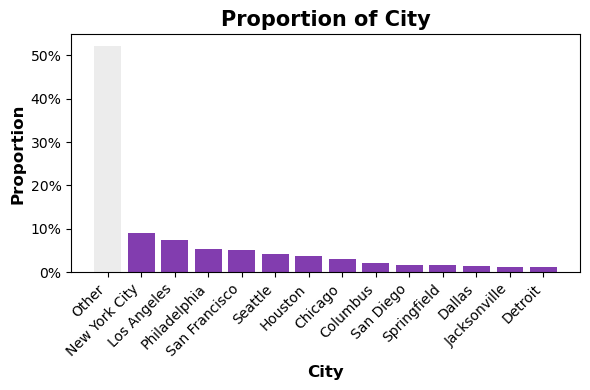

In [26]:
# Calculate Proportion of city
from matplotlib.ticker import FuncFormatter


df = us_merged_df.copy()
city_counts = df['city'].value_counts(normalize=True)
# Create a new column based on the proportion
df['group'] = df['city'].apply(lambda x: x if city_counts[x] > 0.01 else 'Other')
# Calculate proportion for each group
group_props = df['group'].value_counts(normalize=True)
# Reorder the group by size
group_props = group_props.sort_values(ascending=False)

# Create the plot
plt.figure(figsize=(6, 4))
plt.bar(group_props.index, group_props.values, color = ['#ececec' if group == 'Other' else "#823daf" for group in group_props.index])

# Format the plot
plt.xlabel("City", fontsize=12, fontweight='bold')
plt.ylabel("Proportion", fontsize=12, fontweight='bold')
plt.title("Proportion of City", fontsize=15, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.0%}"))

# Add layout
plt.tight_layout()
plt.show()

### **Date Type Variable**

Let's extract more inforamtion from date parts and analyze them.

**Order Date**

In [27]:
# Select only date columns
date_df = us_merged_df.select_dtypes(include=['datetime64']) 
# summary statistics for date columns
print(date_df.describe())

                          order_date                      ship_date
count                           9994                           9994
mean   2013-04-30 19:20:02.401440768  2013-05-04 18:20:49.229537792
min              2011-01-04 00:00:00            2011-01-08 00:00:00
25%              2012-05-23 00:00:00            2012-05-27 00:00:00
50%              2013-06-27 00:00:00            2013-06-30 00:00:00
75%              2014-05-15 00:00:00            2014-05-19 00:00:00
max              2014-12-31 00:00:00            2015-01-06 00:00:00


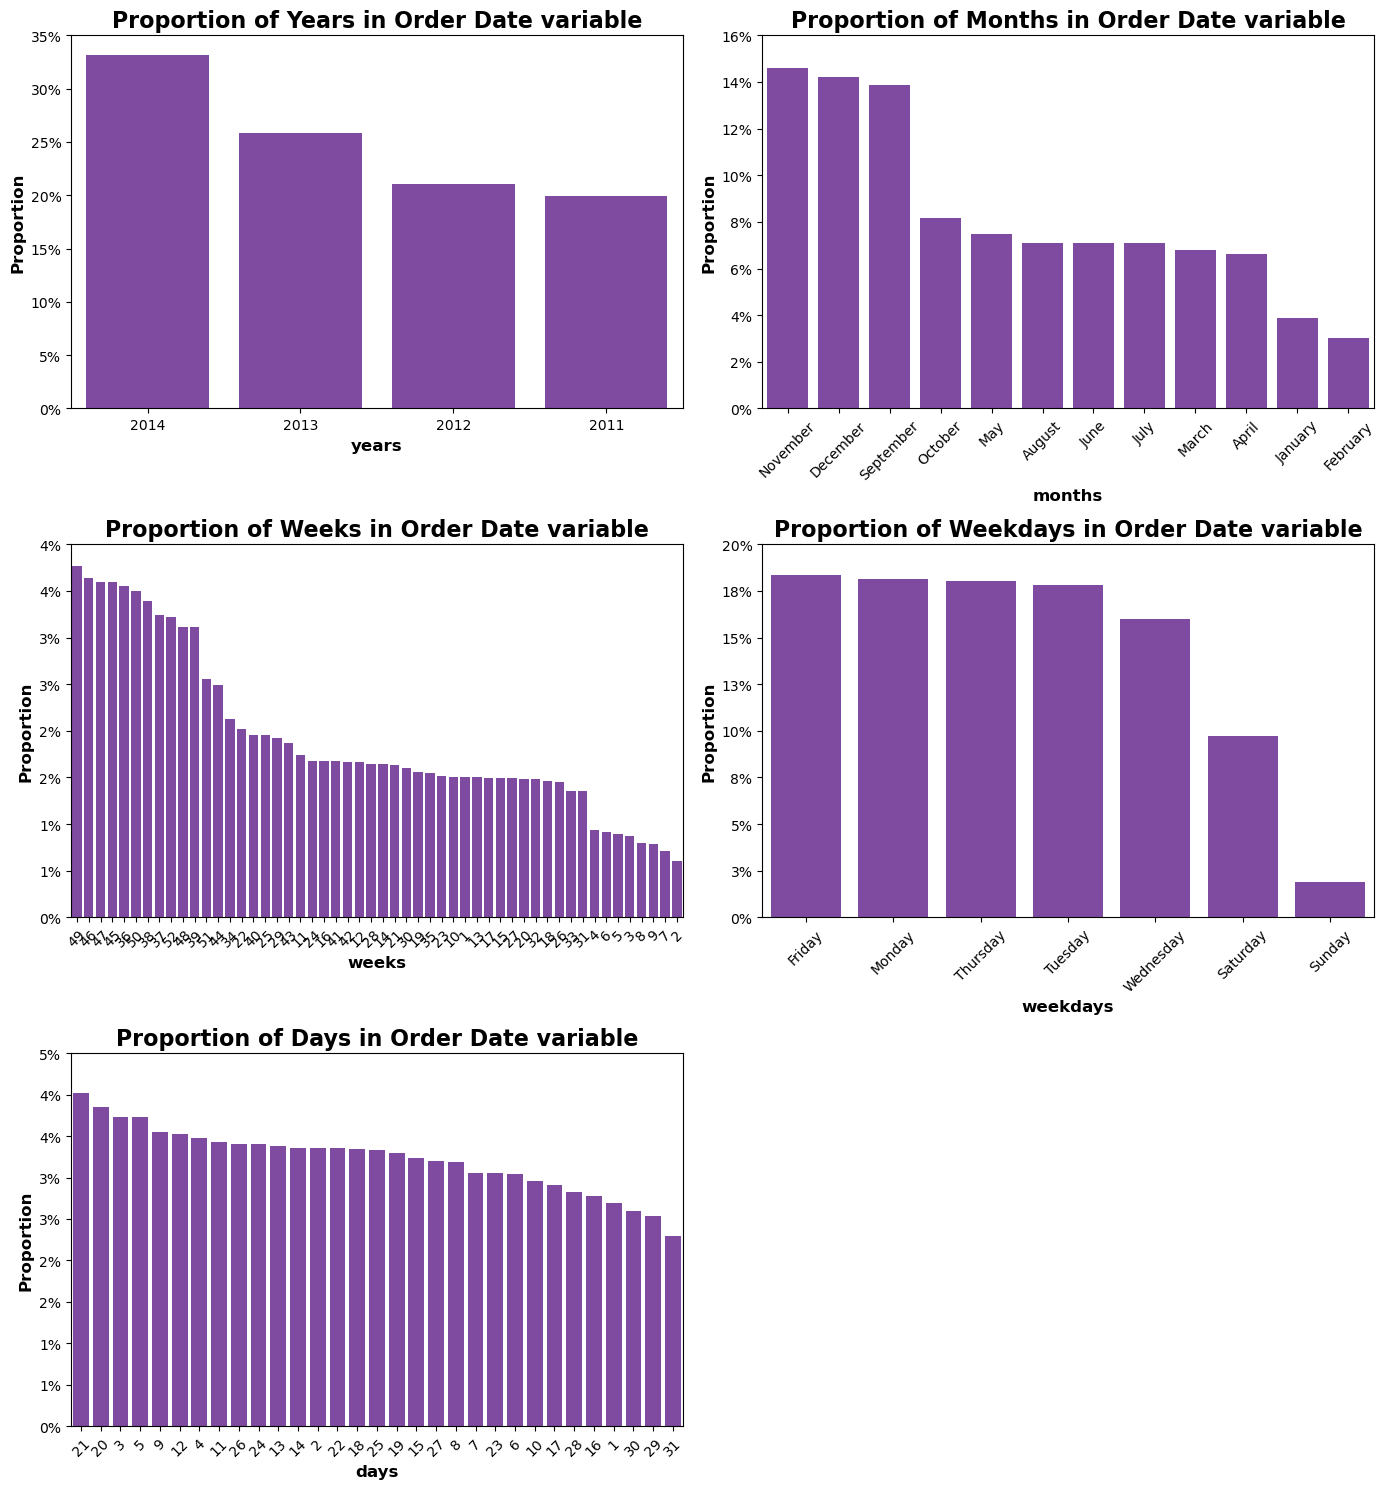

In [28]:
data = date_df.copy()

# Create new columns from 'Order Date'
data['years'] = data['order_date'].dt.year.astype('category')
data['months'] = data['order_date'].dt.month_name().astype('category')
data['weeks'] = data['order_date'].dt.isocalendar().week.astype('category')
data['weekdays'] = data['order_date'].dt.day_name().astype('category')
data['days'] = data['order_date'].dt.day.astype('category')

# Drop original date columns
order_date_parts = data.drop(columns=['order_date', 'ship_date'], errors='ignore')

# Create plot
# calculate grid size
n_cols = 2
n_rows = math.ceil(len(order_date_parts.columns) / n_cols)

fig, ax = plt.subplots(n_rows, n_cols, figsize=(14, 5*n_rows))
ax = ax.flatten()  # for 1-D array

for i, part in enumerate(order_date_parts.columns):
    sns.countplot(
    data=order_date_parts,
    x=part,
    order=order_date_parts[part].value_counts().index,
    color="#823daf", ax=ax[i])
    
    # Format y-axis as proportions
    total = len(order_date_parts[part])
    ax[i].set_yticks(ax[i].get_yticks())
    ax[i].set_yticklabels([f"{y/total:.0%}" for y in ax[i].get_yticks()])
    
    # Labels and formatting
    ax[i].set_xlabel(part, fontsize=12, fontweight='bold')
    ax[i].set_ylabel("Proportion", fontsize=12, fontweight='bold')
    ax[i].set_title(f"Proportion of {part.capitalize()} in Order Date variable", fontsize=16, fontweight='bold')
    
    # Rotate x labels if too many categories
    if order_date_parts[part].nunique() > 4:
        ax[i].tick_params(axis='x', rotation=45)
    else:
        ax[i].tick_params(axis='x', rotation=0)

# Hide unused subplots
for j in range(len(order_date_parts.columns), len(ax)):
    fig.delaxes(ax[j])

# Add layout  
plt.tight_layout()
plt.show()

**Ship Date**

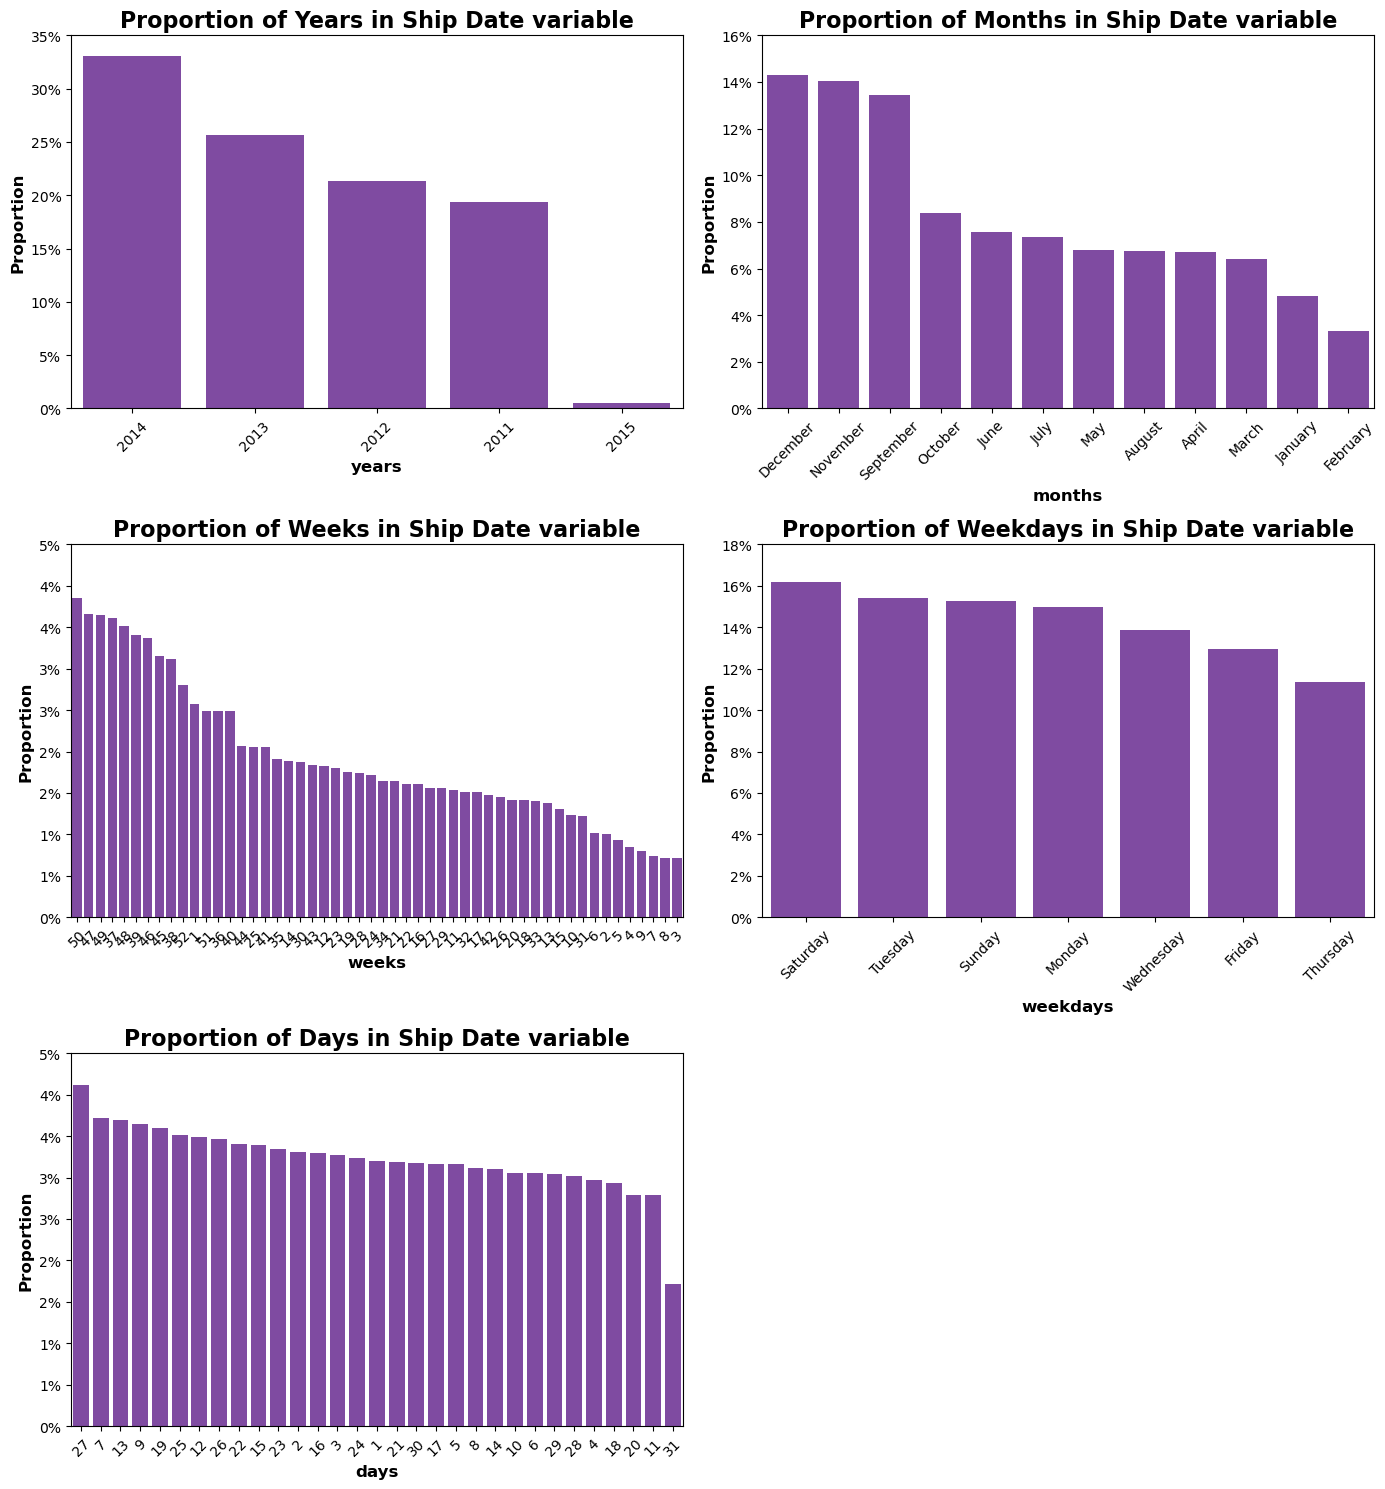

In [29]:

new_data = date_df.copy()

# Create new columns from 'Order Date'
new_data['years'] = new_data['ship_date'].dt.year.astype('category')
new_data['months'] = new_data['ship_date'].dt.month_name().astype('category')
new_data['weeks'] = new_data['ship_date'].dt.isocalendar().week.astype('category')
new_data['weekdays'] = new_data['ship_date'].dt.day_name().astype('category')
new_data['days'] = new_data['ship_date'].dt.day.astype('category')

# Drop original date columns
ship_date_parts = new_data.drop(columns=['order_date', 'ship_date'], errors='ignore')

# calculate grid size
n_cols = 2
n_rows = math.ceil(len(ship_date_parts.columns) / n_cols)

fig, ax = plt.subplots(n_rows, n_cols, figsize=(14, 5*n_rows))
ax = ax.flatten()  # for 1-D array

for i, part in enumerate(ship_date_parts.columns):
    sns.countplot(
    data=ship_date_parts,
    x=part,
    order=ship_date_parts[part].value_counts().index,
    color="#823daf", ax=ax[i])
    
    # Format y-axis as proportions
    total = len(ship_date_parts[part])
    ax[i].set_yticks(ax[i].get_yticks())
    ax[i].set_yticklabels([f"{y/total:.0%}" for y in ax[i].get_yticks()])
    
    # Labels and formatting
    ax[i].set_xlabel(part, fontsize=12, fontweight='bold')
    ax[i].set_ylabel("Proportion", fontsize=12, fontweight='bold')
    ax[i].set_title(f"Proportion of {part.capitalize()} in Ship Date variable", fontsize=16, fontweight='bold')
    
    # Rotate x labels if too many categories
    if ship_date_parts[part].nunique() > 4:
        ax[i].tick_params(axis='x', rotation=45)
    else:
        ax[i].tick_params(axis='x', rotation=0)

# Hide unused subplots
for j in range(len(ship_date_parts.columns), len(ax)):
    fig.delaxes(ax[j])

# Add layout  
plt.tight_layout()
plt.show()

**Numeric Variabels**

In [30]:
# highlight values
def highlighted_values(val):
    if pd.isna(val):
        return "background-color:gray"
    elif val==0:
        return "background-color:yellow; color:black"
    elif val < 0:
        return "background-color:red; color:white"
    else:
        return ""

In [31]:
cont_df = us_merged_df.describe(include=['number'])
display(cont_df.style.applymap(highlighted_values))

,row_id,postal_code,sales,quantity,discount,profit,shipping_cost
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,36293.500000,55190.379428,229.858001,3.789574,0.156203,28.656896,23.831678
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108,58.962848
min,31297.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.010000
25%,33795.250000,23223.000000,17.280000,2.000000,0.000000,1.728750,1.490000
50%,36293.500000,56430.500000,54.490000,3.000000,0.200000,8.666500,5.100000
75%,38791.750000,90008.000000,209.940000,5.000000,0.200000,29.364000,19.985000
max,41290.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000,933.570000


**Observations:**

- **Discount :**  The discount column has a lot of zero values, which might indicate that many orders were made without any discount. Or, there is any other reason we need to investigate furthur.

- **Profit :**  The profit column has a negative value which indicates that there are some orders that resulted in a loss and profit value is zero as well which inidicates that there are some orders that did not generate any profit, or these values are some error need to investigate furthur.


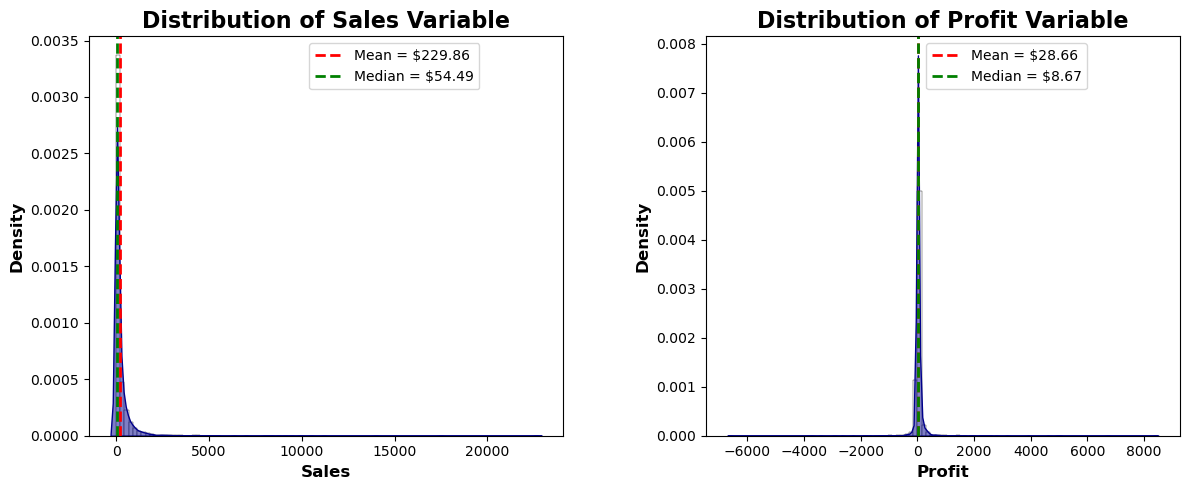

In [32]:
# creat plot for sales and profit
from cProfile import label

from xarray import Variable
import matplotlib.patches as patches

cts_df = us_merged_df[['sales', 'profit']].copy()
n_cols = 2
n_rows = math.ceil(len(cts_df.columns) / n_cols)
fig, ax = plt.subplots(n_rows, n_cols, figsize=(12, 5*n_rows))
ax = ax.flatten()
for i, col in enumerate(cts_df.columns):
    sns.histplot(cts_df, x= col, bins=100, kde=False, stat='density', color='white', edgecolor='k', ax= ax[i])
    sns.kdeplot(cts_df[col], color='darkblue', fill=True, alpha=0.5, ax=ax[i])

    # Add mean and median line
    ax[i].axvline(cts_df[col].mean(), linestyle='--', linewidth=2, color='red', label=f"Mean = ${cts_df[col].mean():,.2f}")
    ax[i].axvline(cts_df[col].median(), linestyle='--', linewidth=2, color='green', label=f"Median = ${cts_df[col].median():,.2f}")

    # Add label and titles
    ax[i].set_xlabel(col.capitalize(), fontsize=12, fontweight='bold')
    ax[i].set_ylabel('Density', fontsize=12, fontweight='bold')
    ax[i].set_title(f"Distribution of {col.capitalize()} Variable", fontsize=16, fontweight='bold')

    # legend
    ax[i].legend(loc='upper left', bbox_to_anchor=(0.45, 1), ncols=1)

# Add layout
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()


The **Sales and Profit** Variable has right-skewed distributions.

**Discount Variable**

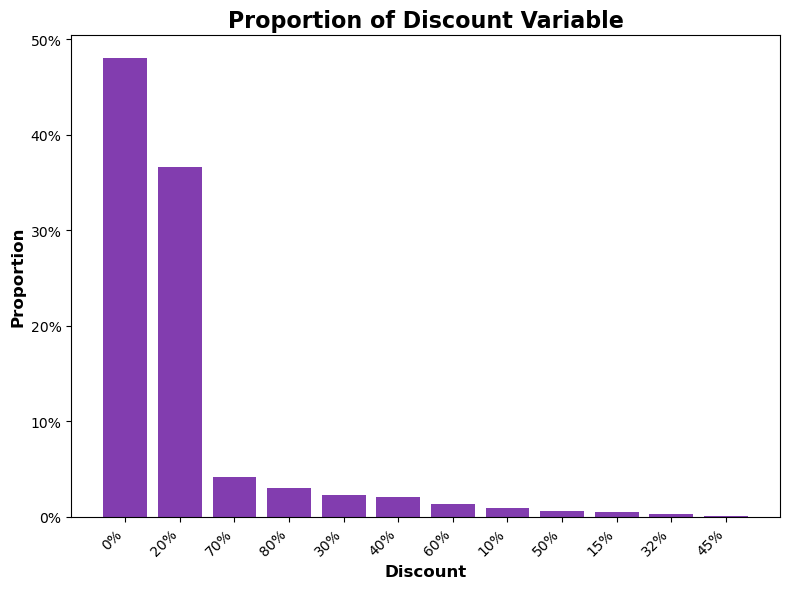

In [33]:
# Convert Discount to percentage labels (like scales::percent in R)
discount_df = us_merged_df.copy()
discount_df['discount'] = discount_df['discount'].apply(lambda x: f"{x*100:.0f}%")
order = discount_df['discount'].value_counts(normalize=True).sort_values(ascending=False)
# Plot proportions
plt.figure(figsize=(8,6))
ax = plt.bar(
    order.index,
    order.values,
    color="#823daf"
)

# Format y-axis as proportions
total = len(df['discount'])
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.0%}"))

# Labels and title
plt.xlabel("Discount", fontsize=12, fontweight='bold')
plt.ylabel("Proportion", fontsize=12, fontweight='bold')
plt.title("Proportion of Discount Variable", fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Quantity Variable**

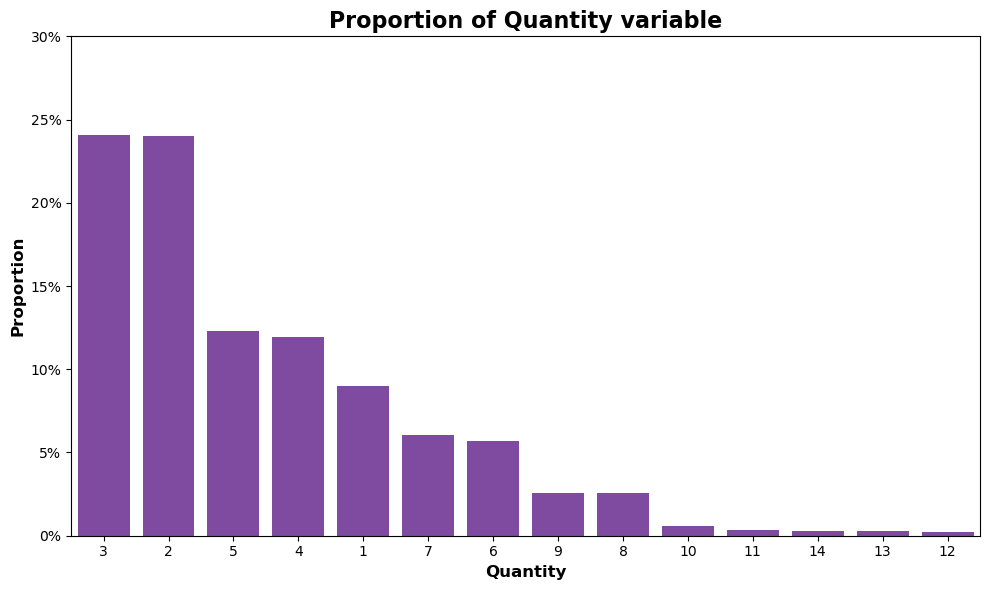

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assume Orders is a pandas DataFrame with a 'Quantity' column
df = us_merged_df.copy()

# Convert Quantity to categorical (like as.factor in R)
df['quantity'] = df['quantity'].astype('category')

# Plot proportions
plt.figure(figsize=(10,6))
ax = sns.countplot(
    data=df,
    x='quantity',
    order=df['quantity'].value_counts().index,
    color="#823daf"
)

# Format y-axis as proportions
total = len(df['quantity'])
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels([f"{y/total:.0%}" for y in ax.get_yticks()])

# Labels and title
plt.xlabel("Quantity", fontsize=12, fontweight='bold')
plt.ylabel("Proportion", fontsize=12, fontweight='bold')
plt.title("Proportion of Quantity variable", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


**Extract features from date columns for furthur analysis**

In [35]:
# Requirement gathering of data for analysis
print(f"Order Date data type: {us_merged_df['order_date'].dtype}",'\n')
print(us_merged_df['order_date'].head(1)) 

Order Date data type: datetime64[ns] 

0   2012-07-31
Name: order_date, dtype: datetime64[ns]


In [36]:
# Create new dimensions from order date column like year, month, week, dayofyear, etc. for seasonal trend
us_merged_df['year'] = us_merged_df['order_date'].dt.year
us_merged_df['n_month'] = us_merged_df['order_date'].dt.month
us_merged_df['month'] =us_merged_df['order_date'].dt.month_name()
us_merged_df['week'] = us_merged_df['order_date'].dt.isocalendar().week
us_merged_df['n_wod'] = us_merged_df['order_date'].dt.isocalendar().day
us_merged_df['wod'] = us_merged_df['order_date'].dt.day_name()
us_merged_df['dayofyear'] = us_merged_df['order_date'].dt.dayofyear   
us_merged_df['quarter'] = us_merged_df['order_date'].dt.quarter

display("Newly created date dimensions:", us_merged_df[['order_date','year', 'n_month', 'month', 'week', 'n_wod', 'wod', 'dayofyear', 'quarter']].head(4))


'Newly created date dimensions:'

,order_date,year,n_month,month,week,n_wod,wod,dayofyear,quarter
0,2012-07-31,2012,7,July,31,2,Tuesday,213,3
8,2014-10-14,2014,10,October,42,2,Tuesday,287,4
9,2012-01-28,2012,1,January,4,6,Saturday,28,1
10,2011-04-05,2011,4,April,14,2,Tuesday,95,2


# **Exploratory Data Analysis**

In [37]:
# range of  year in dataset
min_year = us_merged_df['year'].min()
latest_year = us_merged_df['year'].max()

print(f"Year Ranges: {min_year}-{latest_year}")

Year Ranges: 2011-2014


## **General Metrics**

- what is gross sales revenue?
- what is total profit?
- what is total number of customers?
- what is new number of customers?
- what is average basket size and value?
- what is customer lifetime value (CLV)?

**Let's find out general metrics for latest year. It's 2014 year in this dataset.**

**Calculation of General Metrics**

**What is gross sales revenue?**

In [38]:
#Step 1: Aggregate sales and profit by year
from re import sub
from click import group, style


group_df = (
    us_merged_df.groupby(['year'],as_index=False)
    .agg(
        {'sales': 'sum', 'profit': 'sum'}
    )
    .round(2)
    .sort_values('year')
)

#Step 2: Compute YoY sales and profit growth
group_df['yoy_sales_growth'] = group_df['sales'].pct_change().round(2)
group_df['yoy_profit_growth'] = group_df['profit'].pct_change().round(2)

# Reorder columns
group_df = group_df[['year', 'sales', 'yoy_sales_growth', 'profit', 'yoy_profit_growth']]

# Format function

def format_dollar(val):
    return f"${val:,.2f}" if pd.notna(val) else ""

def percent_fmt(val):
    return f"{val:.1%}" if pd.notna(val) else ""

# Apply formatting
styled_df = (
    group_df
    .rename(columns={'year': 'Year'})
    .assign(
        Sales = group_df['sales'].apply(format_dollar),
        YoY_Sales_Growth = group_df['yoy_sales_growth'].apply(percent_fmt),
        Profit = group_df['profit'].apply(format_dollar),
        YoY_Profit_Growth = group_df['yoy_profit_growth'].apply(percent_fmt)
    )
    .drop(columns=['sales', 'yoy_sales_growth', 'profit', 'yoy_profit_growth'])
    .style
    .applymap(lambda val : "color: red" if isinstance(val, str) and val.startswith("-") else "color:green", subset=['YoY_Sales_Growth', 'YoY_Profit_Growth'])
    .set_caption("Yearly Sales and Profit with YoY Growth Rates")
    .set_table_styles([
        dict(
            selector = "caption",
             props = [('text-align', 'center'),
                      ('font-size', '100%'),
                      ('font-weight', 'bold'),
                      ('color', 'k')]
        )]
                )
    .hide(axis='index')
)

display(styled_df)

Year,Sales,YoY_Sales_Growth,Profit,YoY_Profit_Growth
2011,"$484,247.50",,"$49,543.97",
2012,"$470,532.51",-3.0%,"$61,618.60",24.0%
2013,"$608,473.83",29.0%,"$81,726.93",33.0%
2014,"$733,947.02",21.0%,"$93,507.51",14.0%


posx and posy should be finite values
posx and posy should be finite values


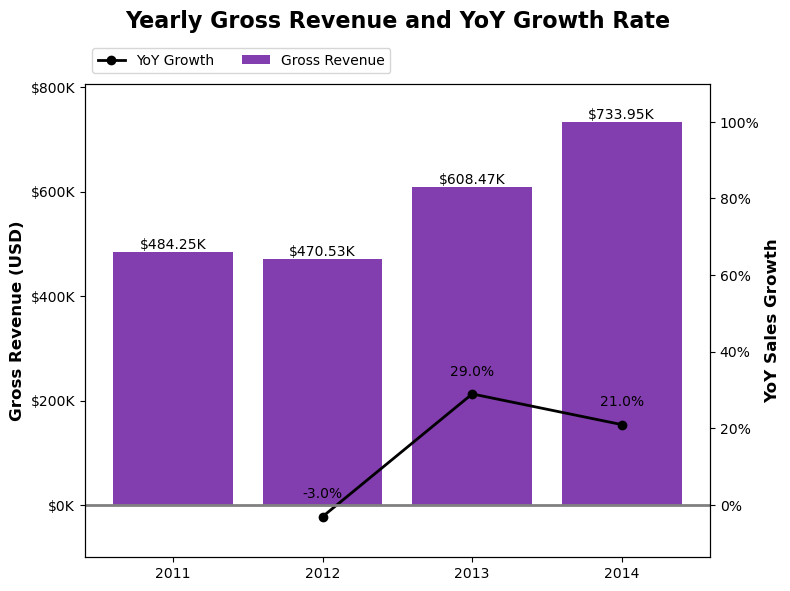

In [39]:
# Visualization of sales its YoY Growth rate

sales_df = group_df[['year','sales', 'yoy_sales_growth']].copy()

scale = sales_df['sales'].max()

# Create plot
fig, ax = plt.subplots(figsize=(8,6))
# Bar plot for sales
ax.bar(
    sales_df['year'],
    sales_df['sales'],
    color="#823daf",
    label='Gross Revenue'
)
# Line plot for YoY sales growth
ax.plot(
    sales_df['year'],
    sales_df['yoy_sales_growth'] * scale,  # Scale growth for visibility
    linewidth = 2, linestyle= 'solid',
    color='k',
    marker='o', markersize=6,
    label='YoY Growth'
)
# Annotate growth points and sales values
for i, row in sales_df.iterrows():
    ax.text(
        row['year'],
        row['sales'] + 1000 ,
        f"${row['sales']/1000:.2f}K", 
        ha='center', va='bottom', fontsize=10
    )
    ax.text(
        row['year'],
        row['yoy_sales_growth'] * scale + 0.04 * scale,
        f"{row['yoy_sales_growth']:.1%}",
        ha='center', va='bottom', fontsize=10
    )
# Add horizontal line at y=0 for growth rate reference
ax.axhline(0, color='gray', linewidth=2, linestyle='solid')

# Secondary y-axis for growth rate
ax.set_ylim(-100000, scale * 1.1)
ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim()[0]/scale, ax.get_ylim()[1]/scale)
ax2.set_yticklabels([f"{y:.0%}" for y in ax2.get_yticks()])

# Format y-axis of primary axis and x-axis
ax.set_yticklabels([f"${y/1000:.0f}K" for y in ax.get_yticks()])
ax.set_xticks(np.sort(sales_df['year'].unique()))

# Labels and title
ax.set_xlabel("")
ax.set_ylabel("Gross Revenue (USD)", fontsize=12, fontweight='bold')
ax2.set_ylabel("YoY Sales Growth", fontsize=12, fontweight='bold')
ax.set_title("Yearly Gross Revenue and YoY Growth Rate", fontsize=16, fontweight='bold', y=1.10)

# Add legend
ax.legend(loc='upper right', bbox_to_anchor=(0.5, 1.09), ncols=2)

# Add layout
plt.tight_layout()
plt.show()

**Observations:**

- Total Revenue in 2014 is $733.92 K and the total amount of revenue shows an increasing trend year over year except in 2012. 

- YoY sales growth rate on 8% in 2014 vs previous year, that showed more than 30% growth from negative position in 2012. 

**What is total profit and YoY Growth Rate of its?**

posx and posy should be finite values
posx and posy should be finite values


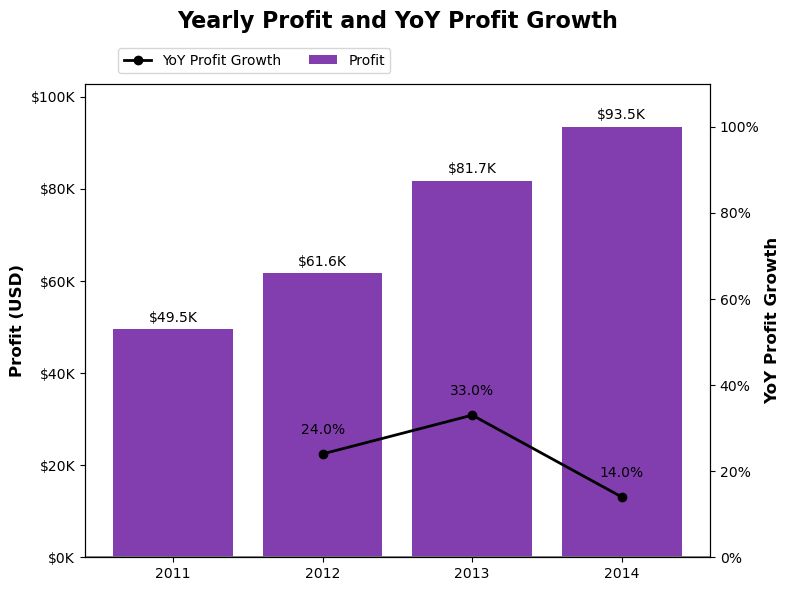

In [40]:
profit_df = group_df[group_df.columns[group_df.columns.str.contains('profit|year', regex=True)]]

# Visualization of profit and its YoY Growth rate

scale = profit_df['profit'].max()

# Create plot
fig, ax = plt.subplots(figsize=(8,6))
# Bar plot for sales
ax.bar(
    profit_df['year'],
    profit_df['profit'],
    color="#823daf",
    label='Profit'
)
# Line plot for YoY sales growth
ax.plot(
    profit_df['year'],
    profit_df['yoy_profit_growth'] * scale,  # Scale growth for visibility
    linewidth = 2, linestyle= 'solid',
    color='k',
    marker='o', markersize=6,
    label='YoY Profit Growth'
)
# Annotate growth points and sales values
for i, row in profit_df.iterrows():
    ax.text(
        row['year'],
        row['profit'] + 1000 ,
        f"${row['profit']/1000:.1f}K", 
        ha='center', va='bottom', fontsize=10
    )
    ax.text(
        row['year'],
        row['yoy_profit_growth'] * scale + 0.04 * scale,
        f"{row['yoy_profit_growth']:.1%}",
        ha='center', va='bottom', fontsize=10
    )
# Add horizontal line at y=0 for growth rate reference
ax.axhline(0, color='gray', linewidth=2, linestyle='solid')

# Secondary y-axis for growth rate
ax.set_ylim(0, scale * 1.1)
ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim()[0]/scale, ax.get_ylim()[1]/scale)
ax2.set_yticklabels([f"{y:.0%}" for y in ax2.get_yticks()])

# Format y-axis of primary axis and x-axis
ax.set_yticklabels([f"${y/1000:.0f}K" for y in ax.get_yticks()])
ax.set_xticks(np.sort(profit_df['year'].unique()))

# Labels and title
ax.set_xlabel("")
ax.set_ylabel("Profit (USD)", fontsize=12, fontweight='bold')
ax2.set_ylabel("YoY Profit Growth", fontsize=12, fontweight='bold')
ax.set_title("Yearly Profit and YoY Profit Growth", fontsize=16, fontweight='bold', y=1.10)

# Add legend
ax.legend(loc='upper right', bbox_to_anchor=(0.5, 1.09), ncols=2)

# Add layout
plt.tight_layout()
plt.show()

**Observations :**

- Total amount of profit shows an increasing upward growth YoY in absoulte number.

- YoY profit growth rate dropped on 19% vs previous year.

**What are Sales and Average Price Quarterly?**

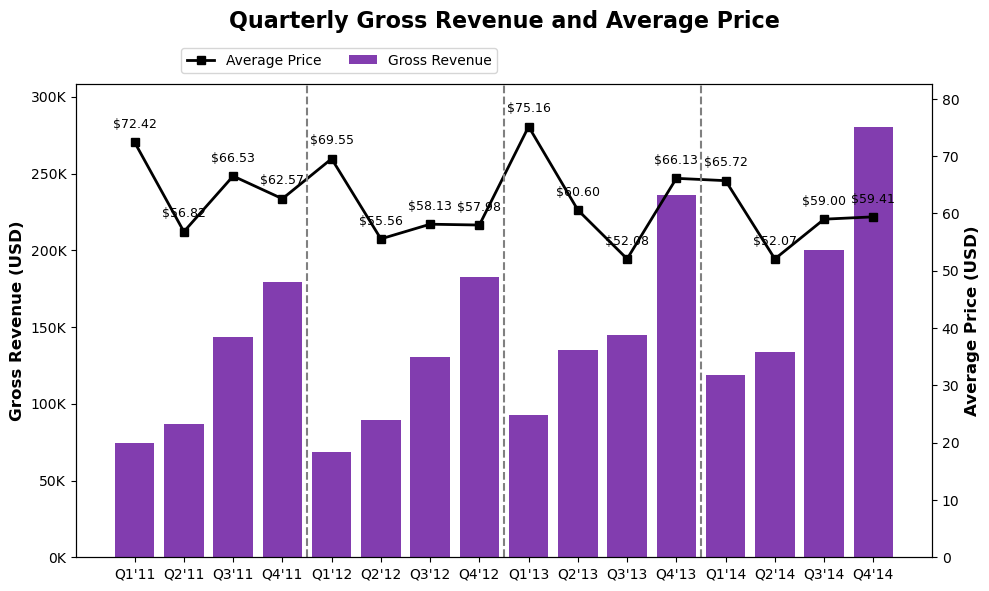

In [41]:
sales_price_df = (
    us_merged_df.groupby(['year', 'quarter'], as_index=False)
    .agg({'sales': 'sum', 'quantity': 'sum'})
    .round(2)
)

sales_price_df['price'] = sales_price_df['sales'] / sales_price_df['quantity']
sales_price_df['qy'] = ["Q{}'{}".format(q, str(y)[-2:]) for q, y in zip(sales_price_df['quarter'], sales_price_df['year'])]
sales_price_df['n'] = sales_price_df.index + 1
sales_price_df.head()
# Sort by n to maintain order
sales_price_df = sales_price_df.sort_values('n')
# visualization of sales_price_df
scale = sales_price_df['sales'].max() / sales_price_df['price'].max()
fig, ax = plt.subplots(figsize=(10,6))

# bar plots for sales
ax.bar(
    sales_price_df['qy'],
    sales_price_df['sales'],
    color="#823daf",
    label='Gross Revenue'
)
# Line plot for average price
ax.plot(
    sales_price_df['qy'],
    sales_price_df['price'] * scale,
    color='k',
    linewidth=2, linestyle='solid',
    marker='s', markersize=6,
    label='Average Price'
)
# Add text labels for sales and price
for i, row in sales_price_df.iterrows():
    #ax.text(row['qy'],
    #row['sales']+1000, f"{row['sales']/1000:.2f}K",
    #ha='center', va='bottom', fontsize=9)

    ax.text(row['qy'],
    row['price'] * scale + 2 * scale, f"${row['price']:.2f}",
    ha='center', va='bottom', fontsize=9)

# Add Vertical lines for each year separation
for x in np.arange(4, len(sales_price_df['qy']), 4):
    ax.axvline(x-0.5, color='gray', linewidth=1.5, linestyle='--')

# Adjust y-axis limits
ax.set_ylim(0, sales_price_df['sales'].max() * 1.1)

# Secondary y-axis for price
ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim()[0]/scale, ax.get_ylim()[1]/scale)
ax2.set_yticklabels([f"{y:.0f}" for y in ax2.get_yticks()])

# Format y-axis of primary axis and x-axis
ax.set_yticklabels([f"{y/1000:.0f}K" for y in ax.get_yticks()])
ax.set_xlabel("")

# Labels and title
ax.set_ylabel("Gross Revenue (USD)", fontsize=12, fontweight='bold')
ax2.set_ylabel("Average Price (USD)", fontsize=12, fontweight='bold')
ax.set_title("Quarterly Gross Revenue and Average Price", fontsize=16, fontweight='bold', y=1.10)

# Legend
ax.legend(loc='upper right', bbox_to_anchor=(0.5, 1.09), ncols=2)

# Add layout
plt.tight_layout()
plt.show()

**What are sales and average price per quarter per segment?**

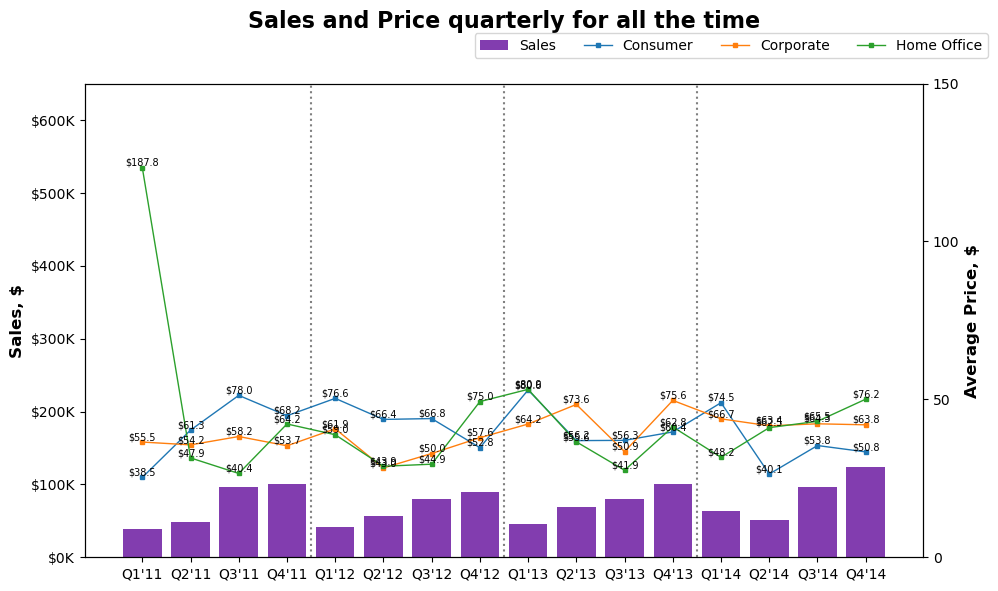

In [42]:
sales_price_df = (
    us_merged_df.groupby(['year', 'quarter','segment'], as_index=False)
    .agg({'sales': 'sum', 'quantity': 'sum'})
    .round(2)
)

sales_price_df['price'] = sales_price_df['sales'] / sales_price_df['quantity']
sales_price_df['qy'] = ["Q{}'{}".format(q, str(y)[-2:]) for q, y in zip(sales_price_df['quarter'], sales_price_df['year'])]
sales_price_df['n'] = sales_price_df.index + 1
sales_price_df.head()
# Sort by n to maintain order
sales_price_df = sales_price_df.sort_values('n')
# visualization of sales_price_df
scale = sales_price_df['sales'].max() / sales_price_df['price'].max()

fig, ax = plt.subplots(figsize=(10,6))

# Bars for Sales
ax.bar(sales_price_df["qy"], sales_price_df["sales"], color="#823daf", label="Sales")

# Secondary axis for Avg. Price
ax2 = ax.twinx()

# Plot separate lines per Segment
for seg, df in sales_price_df.groupby("segment"):
    ax2.plot(df["qy"], df["price"]*scale, marker="s", markersize=3,
             linewidth=1, label=seg)

    # Add labels for each point
    for x, y in zip(df["qy"], df["price"]*scale):
        ax2.text(x, y, f"${y/scale:.1f}", ha="center", va="bottom", fontsize=7)

# Vertical dotted lines
for xpos in [3.5, 7.5, 11.5]:
    ax.axvline(x=xpos, linestyle="dotted", color="gray")


# Format y-axis and secondary axis limits
ax.set_ylim(0, 650000)
ax.set_yticks(range(0, 650001, 100000))
ax.set_yticklabels([f"${y/1000:.0f}K" for y in ax.get_yticks()])
ax2.set_ylim(0, 150000)
ax2.set_yticks(range(0, 150001, 50000))
ax2.set_yticklabels([f"{y/1000:.0f}" for y in ax2.get_yticks()])


# Add labels and title
ax.set_ylabel("Sales, $", fontsize=12, fontweight="bold")
ax2.set_ylabel("Average Price, $", fontsize=12, fontweight="bold")
ax.set_title("Sales and Price quarterly for all the time", fontsize=16, fontweight="bold", y=1.10)
ax.set_xlabel("")

# Add legend
fig.legend(loc='upper right', bbox_to_anchor=(1, 0.95), ncols= 4)


plt.tight_layout()
plt.show()


**What is Average Order Value by Month?**

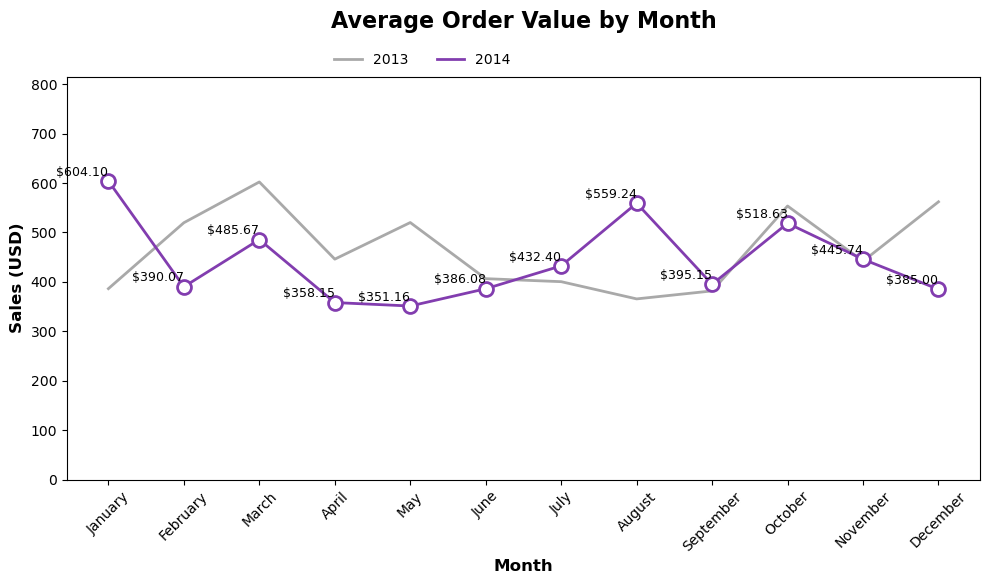

In [43]:
# Aggregate by order_id
from matplotlib import lines


order_df = (
    us_merged_df.groupby('order_id', as_index=False)
    .agg({'sales' : 'sum', 'order_date':'first'})
)
# Extract year and month
order_df['year'] = order_df['order_date'].dt.year
order_df['month'] = order_df['order_date'].dt.month

# Average sales per order by year and month
avg_order_df = (
    order_df.groupby(['year', 'month'], as_index=False)
    .agg(avg_sales = ('sales', 'mean'))
    .round(2)

)
avg_order_df['month_name'] = avg_order_df['month'].apply(lambda x: pd.to_datetime(str(x), format='%m').month_name())

# Filter for 2013, 2014 years
avg_order_df = avg_order_df[avg_order_df['year'].isin([2013, 2014])].reset_index(drop=True)

# Create the plot
plt.figure(figsize=(10,6))
sns.lineplot(
    data=avg_order_df,
    x='month_name',
    y='avg_sales',
    hue='year',
    palette = {2013:'darkgray', 2014:'#823daf'},
    linewidth=2
)
# Points for 2014 year
sns.scatterplot(data = avg_order_df[avg_order_df['year']==2014],
                x='month_name',
                y='avg_sales',
                facecolor='white',
                edgecolor='#823daf',
                s=100,
                zorder=2,
                linewidth=2)

# Add labels for year 2014 points
for i, row in avg_order_df[avg_order_df['year']==2014].iterrows():
    plt.text(
        row['month_name'],
        row['avg_sales']+5,
        f"${row['avg_sales']:.2f}",
        ha='right', va='bottom',
        fontsize=9, color='k'
    )

# Format y-axis limit
plt.ylim(0, avg_order_df['avg_sales'].max() * 1.35)
plt.yticks(range(0, int(avg_order_df['avg_sales'].max() * 1.35), 100))

# Labels and title
plt.xlabel("Month", fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel("Sales (USD)", fontsize=12, fontweight='bold')
plt.title("Average Order Value by Month", fontsize=16, fontweight='bold', y=1.10)

# Add legend
plt.legend(loc='upper right', bbox_to_anchor = (0.5, 1.09), ncols=2, frameon=False)
# Add layout
plt.tight_layout()
plt.show()

**What is Average Order Value by Week?**

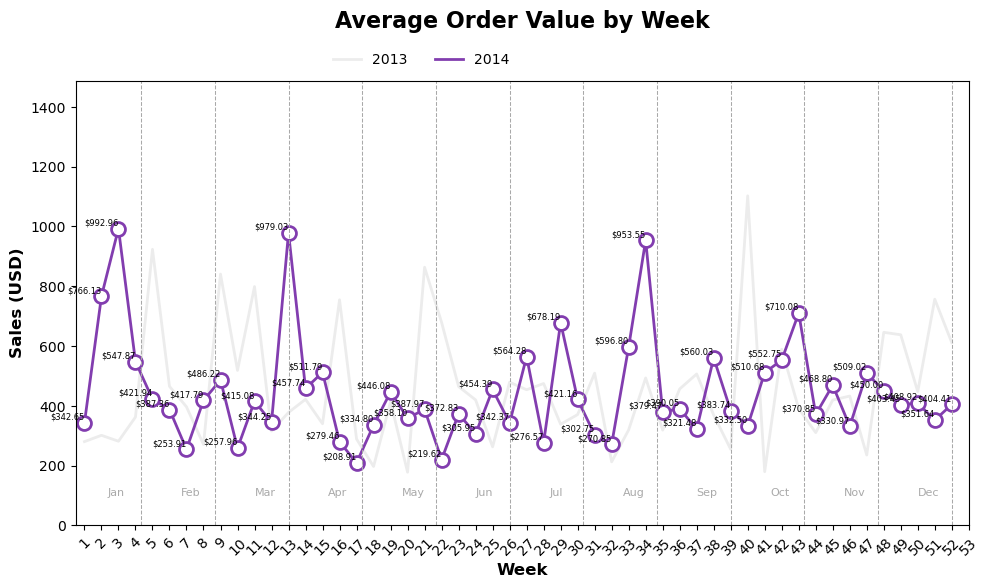

In [44]:
# Aggregate by order_id
from matplotlib import lines
import math


week_df = (
    us_merged_df.groupby('order_id', as_index=False)
    .agg({'sales' : 'sum', 'order_date':'first'})
)
# Extract year and month
week_df['year'] = week_df['order_date'].dt.year
week_df['week'] = week_df['order_date'].dt.isocalendar().week

# Average sales per order by year and week
avg_week_df = (
    week_df.groupby(['year', 'week'], as_index=False)
    .agg(avg_sales = ('sales', 'mean'))
    .round(2)

)


# Filter for 2013, 2014 years
avg_week_df = avg_week_df[avg_week_df['year'].isin([2013, 2014])].reset_index(drop=True)

# Create the plot
plt.figure(figsize=(10,6))
sns.lineplot(
    data=avg_week_df,
    x='week',
    y='avg_sales',
    hue='year',
    palette = {2013:'#ececec', 2014:'#823daf'},
    linewidth=2
)
# Points for 2014 year
sns.scatterplot(data = avg_week_df[avg_week_df['year']==2014],
                x='week',
                y='avg_sales',
                facecolor='white',
                edgecolor='#823daf',
                s=100,
                zorder=2,
                linewidth=2)

# Add labels for year 2014 points
for i, row in avg_week_df[avg_week_df['year']==2014].iterrows():
    plt.text(
        row['week'],
        row['avg_sales']+5,
        f"${row['avg_sales']:.2f}",
        ha='right', va='bottom',
        fontsize=6, color='k'
    )

# Format x-axis ticks
plt.margins(x=0.01)
plt.xticks(range(1, 54),rotation=45)

# Vertical lines for months
for i in range(1, 13):
    week_pos = i * (52/12)
    plt.axvline(x=week_pos, linestyle='--', color='darkgray', linewidth=0.75)

    
    # Month labels
    plt.text(
        x=week_pos - 2,
        y=100,
        s=pd.to_datetime(f'2017-{i}-01').strftime('%b'),
        size=8,
        color='darkgray'
    )


# Format y-axis limit
plt.ylim(0, avg_week_df['avg_sales'].max() * 1.35)
plt.yticks(range(0, int(avg_week_df['avg_sales'].max() * 1.35), 200))

# Labels and title
plt.xlabel("Week", fontsize=12, fontweight='bold')
plt.ylabel("Sales (USD)", fontsize=12, fontweight='bold')
plt.title("Average Order Value by Week", fontsize=16, fontweight='bold', y=1.10)

# Add legend
plt.legend(loc='upper right', bbox_to_anchor = (0.5, 1.09), ncols=2, frameon=False)

# Add layout
plt.tight_layout()
plt.show()

**What is Average Order Value by Date?**

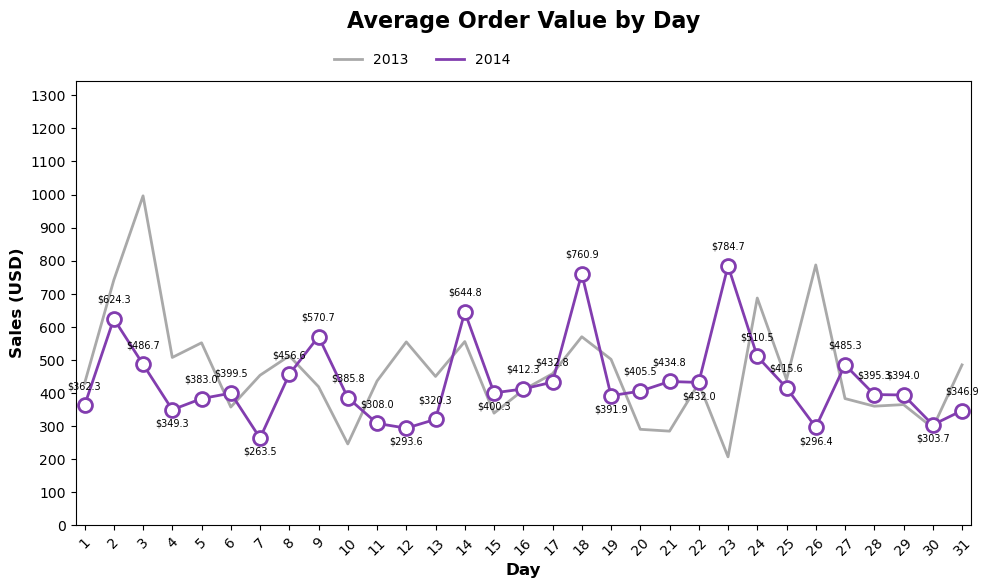

In [45]:
# Aggregate by order_id
from matplotlib import lines


day_df = (
    us_merged_df.groupby('order_id', as_index=False)
    .agg({'sales' : 'sum', 'order_date':'first'})
)
# Extract year and month
day_df['year'] = day_df['order_date'].dt.year
day_df['day'] = day_df['order_date'].dt.day

# Average sales per order by year and day
avg_day_df = (
    day_df.groupby(['year', 'day'], as_index=False)
    .agg(avg_sales = ('sales', 'mean'))
    .round(2)

)
# Filter for 2013, 2014 years
avg_day_df = avg_day_df[avg_day_df['year'].isin([2013, 2014])].reset_index(drop=True)

# Create the plot
plt.figure(figsize=(10,6))
sns.lineplot(
    data=avg_day_df,
    x='day',
    y='avg_sales',
    hue='year',
    palette = {2013:'darkgray', 2014:'#823daf'},
    linewidth=2
)
# Points for 2014 year
sns.scatterplot(data = avg_day_df[avg_day_df['year']==2014],
                x='day',
                y='avg_sales',
                facecolor='white',
                edgecolor='#823daf',
                s=100,
                zorder=2,
                linewidth=2)

# Add labels for year 2014 points
#for i, row in avg_day_df[avg_day_df['year']==2014].iterrows():
 #   plt.text(
  #      row['day'],
  #      row['avg_sales']+5,
   #     f"${row['avg_sales']:.2f}",
    #    ha='right', va='bottom',
     #   fontsize=7, color='k'
    #)

subset_2014 = avg_day_df[avg_day_df['year']==2014].copy()
subset_2014 = subset_2014.sort_values('day')

# Shift values to get neighbors
prev_y = subset_2014['avg_sales'].shift(1)
next_y = subset_2014['avg_sales'].shift(-1)

# Decide offset: above if local minimum, else below
offset = np.where(
    (subset_2014['avg_sales'] < prev_y) & (subset_2014['avg_sales'] < next_y),
    -50,   # above
    50   # below
)

# Add labels
for day, y, dy in zip(subset_2014['day'], subset_2014['avg_sales'], offset):
    plt.text(day, y+dy, f"${y:.1f}", ha='center', fontsize=7, color='black')


# Format y-axis limit
plt.ylim(0, avg_day_df['avg_sales'].max() * 1.35)
plt.yticks(range(0, int(avg_day_df['avg_sales'].max() * 1.35), 100))

# Labels and title
plt.xlabel("Day", fontsize=12, fontweight='bold')
plt.margins(x=0.01)
day = np.sort(avg_day_df['day'].unique())
plt.xticks(ticks=day, labels= day,rotation=45)
plt.ylabel("Sales (USD)", fontsize=12, fontweight='bold')
plt.title("Average Order Value by Day", fontsize=16, fontweight='bold', y=1.10)

# Add legend
plt.legend(loc='upper right', bbox_to_anchor = (0.5, 1.09), ncols=2, frameon=False)

# Add layout
plt.tight_layout()
plt.show()

**What is average order value by day of week?**

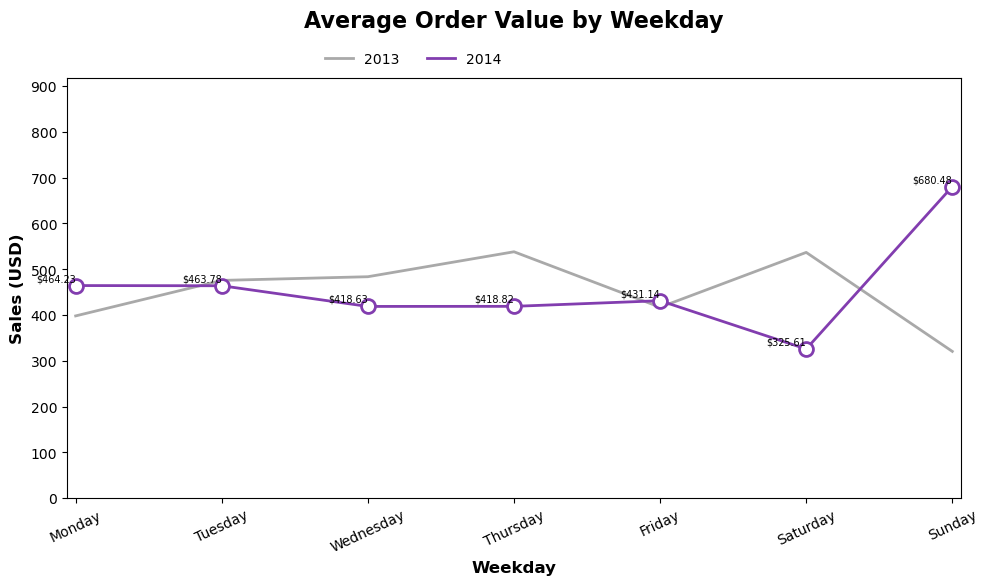

In [46]:
# Aggregate by order_id
from matplotlib import lines


wday_df = (
    us_merged_df.groupby('order_id', as_index=False)
    .agg({'sales' : 'sum', 'order_date':'first'})
)
# Extract year and month
wday_df['year'] = wday_df['order_date'].dt.year
wday_df['wday'] = wday_df['order_date'].dt.dayofweek + 1  # Monday=1, Sunday=7

# Average sales per order by year and day
avg_wday_df = (
    wday_df.groupby(['year', 'wday'], as_index=False)
    .agg(avg_sales = ('sales', 'mean'))
    .round(2)
)
## Map weekday numbers to names
weekday_map = {1:"Monday", 2:"Tuesday", 3:"Wednesday", 4:"Thursday",
               5:"Friday", 6:"Saturday", 7:"Sunday"}
avg_wday_df['week_day'] = avg_wday_df['wday'].map(weekday_map)

# Ensure correct order of weekdays
avg_wday_df['week_day'] = pd.Categorical(avg_wday_df['week_day'],
                                         categories = list(weekday_map.values()),
                                         ordered=True)

# Filter for 2013, 2014 years
avg_wday_df = avg_wday_df[avg_wday_df['year'].isin([2013, 2014])].reset_index(drop=True)

# Create the plot
plt.figure(figsize=(10,6))
sns.lineplot(
    data=avg_wday_df,
    x='week_day',
    y='avg_sales',
    hue='year',
    palette = {2013:'darkgray', 2014:'#823daf'},
    linewidth=2
)
# Points for 2014 year
sns.scatterplot(data = avg_wday_df[avg_wday_df['year']==2014],
                x='week_day',
                y='avg_sales',
                facecolor='white',
                edgecolor='#823daf',
                s=100,
                zorder=2,
                linewidth=2)

# Add labels for year 2014 points
for i, row in avg_wday_df[avg_wday_df['year']==2014].iterrows():
    plt.text(
        row['week_day'],
        row['avg_sales']+5,
        f"${row['avg_sales']:.2f}",
        ha='right', va='bottom',
        fontsize=7, color='k'
    )

subset_2014 = avg_wday_df[avg_wday_df['year']==2014].copy()


# Format y-axis limit
plt.ylim(0, avg_wday_df['avg_sales'].max() * 1.35)
plt.yticks(range(0, int(avg_wday_df['avg_sales'].max() * 1.35), 100))

# Labels and title
plt.xlabel("Weekday", fontsize=12, fontweight='bold')
plt.margins(x=0.01)
plt.xticks(rotation=25)
plt.ylabel("Sales (USD)", fontsize=12, fontweight='bold')
plt.title("Average Order Value by Weekday", fontsize=16, fontweight='bold', y=1.10)

# Add legend
plt.legend(loc='upper right', bbox_to_anchor = (0.5, 1.09), ncols=2, frameon=False)

# Add layout
plt.tight_layout()
plt.show()

**Which Category are best selling and most profitable?**

In [47]:
from matplotlib import category


category_df = (
    us_merged_df.groupby('category', as_index=False)
    .agg({'sales' : 'sum', 'profit':'sum', 'quantity':'sum'})
    .sort_values('sales', ascending=False)
)

# Sum of each columns
totals = category_df[['sales', 'profit', 'quantity']].sum()
new_category_df = category_df.set_index('category')
new_category_df.loc['Grand Total'] = totals
new_category_df = new_category_df.reset_index()

# Style the dataframe for display
style_df = (
    new_category_df.style
    .format({
        'sales' : '${:,.2f}',
        'profit' : '${:,.2f}',
        'quantity' : '{:.0f}'
    })
    .apply(lambda row: ["font-weight: bold" if row.name == new_category_df.index[-1] else "" for _ in row], axis=1)
    .set_caption("Total Sales, Profit and Quantity by Category for all the time")
    .set_table_styles([
        dict(
            selector='caption',
            props=[('text-align', 'center'),
                   ('caption-side', 'top'),
                   ('font-size', '100%'),
                   ('font-weight', 'bold'),
                   ('color', 'k')]
        )
    ])
    .hide(axis='index')
)
style_df

category,sales,profit,quantity
Technology,"$836,154.03","$145,454.95",6939
Furniture,"$741,999.80","$18,451.27",8028
Office Supplies,"$719,047.03","$122,490.80",22906
Grand Total,"$2,297,200.86","$286,397.02",37873


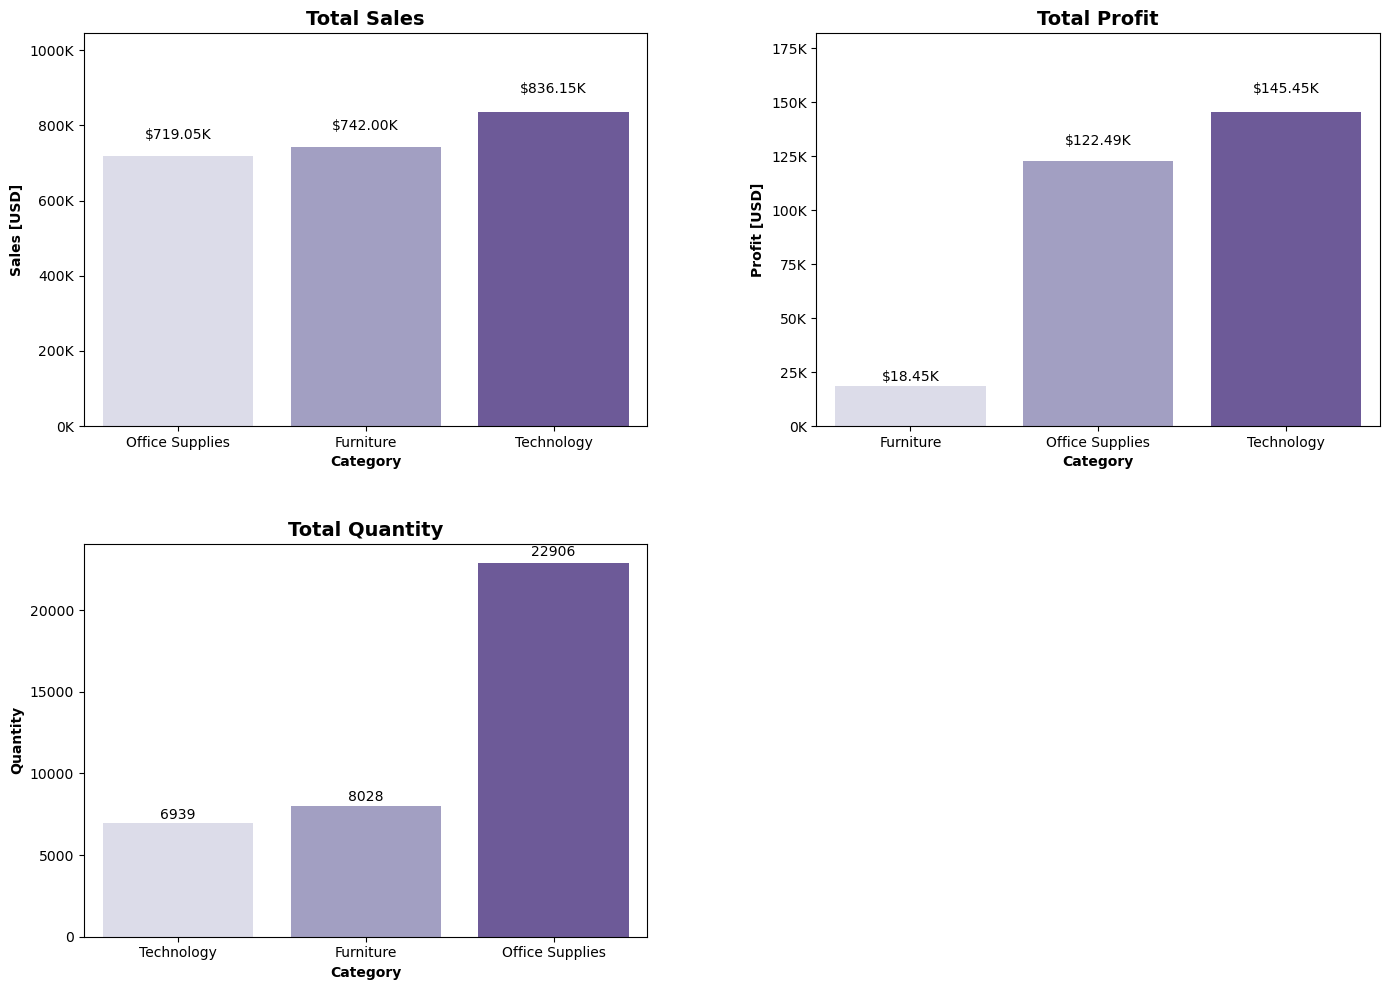

In [48]:
# Visualization of category_df
from altair import FontWeight
from matplotlib.pyplot import delaxes


category_df.reset_index(drop=True)
fig, ax = plt.subplots(2, 2, figsize=(14, 10))
ax = ax.flatten()

# bar plot of sales by category
palette = sns.color_palette('Purples', n_colors = len(category_df['category'].unique()))
sns.barplot(
    data=category_df.sort_values(by='sales'),
    x='category',
    y='sales',
    palette=palette,
    ax=ax[0]
)

# Format y-axis
ax[0].set_ylim(0, category_df['sales'].max() * 1.25)
ax[0].set_yticklabels([f"{val/1000:.0f}K" for val in ax[0].get_yticks()])

# Add labels and title
ax[0].set_xlabel("Category", fontsize=10, fontweight='bold')
ax[0].set_ylabel("Sales [USD]", fontsize=10, fontweight='bold')
ax[0].set_title("Total Sales", fontsize=14, fontweight='bold')

# bar plot of profit by category 
sns.barplot(
    data=category_df.sort_values(by='profit'),
    x='category',
    y='profit',
    palette=palette,
    ax=ax[1]
)
# Format y-axis
ax[1].set_ylim(0, category_df['profit'].max() * 1.25)
ax[1].set_yticklabels([f"{val/1000:.0f}K" for val in ax[1].get_yticks()])

# Add labels and title
ax[1].set_xlabel("Category", fontsize=10, fontweight='bold')
ax[1].set_ylabel("Profit [USD]", fontsize=10, fontweight='bold')
ax[1].set_title("Total Profit", fontsize=14, fontweight='bold')

# Add text labels for sales and profits
for i, row in category_df.iterrows():
    ax[0].text(
        row['category'], row['sales'] * 1.05,
        f"${row['sales']/1000:.2f}K", ha='center', va='bottom',
        fontsize=10, color='k'
    )
    ax[1].text(
        row['category'], row['profit'] * 1.05,
        f"${row['profit']/1000:.2f}K", ha='center', va='bottom',
        fontsize=10, color='k'
    )
    ax[2].text(
        row['category'], row['quantity'] * 1.01,
        f"{row['quantity']:.0f}", ha='center', va='bottom',
        fontsize=10, color='k'
    )
# bar plot of quantity by category
sns.barplot(
    data=category_df.sort_values(by='quantity'),
    x='category',
    y='quantity',
    palette=palette,
    ax=ax[2]
)
# Add labels and title
ax[2].set_xlabel("Category", fontsize=10, fontweight='bold')
ax[2].set_ylabel("Quantity", fontsize=10, fontweight='bold')
ax[2].set_title("Total Quantity", fontsize=14, fontweight='bold')

# Hide unused subplots
fig.delaxes(ax[3])

# Add layout
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()


**Observations:**

- The best selling category is **Technology**, but all three categories make similar sales.
- The most profitable category is **Technology** too. The least profitable category is **Furniture**.
- **Technology** makes similar quantity sold as **Furniture**, but later makes least profit of all the categories.

Let's explore bit deeper. Will explore YoY sales and Profit of Category.

**What is YoY Sales and Profit Growth by Category?**

In [49]:
# Aggregate sales and profit by category + year
sp_df = (
    us_merged_df.groupby(['category', 'year'], as_index=False)
    .agg({'sales': 'sum', 'profit': 'sum'})
    .round(2)
    #.sort_values(by='sales', ascending=False)
)
sp_df['yoy_sales_growth'] = sp_df.groupby(['category'])['sales'].pct_change().round(3)
sp_df['yoy_profit_growth'] = sp_df.groupby(['category'])['profit'].pct_change().round(3)

# Reorder columns
col = ['category', 'year', 'sales', 'yoy_sales_growth', 'profit', 'yoy_profit_growth']
sp_df = sp_df[col]


In [50]:
# Style the sales and profit columns 
pivot_df = sp_df.pivot_table(
    index='category',
    columns = 'year',
    values = ['sales', 'profit'],
    aggfunc= 'sum'
)
styled_df = (
    pivot_df.style
    .format('${:,.2f}')
    .set_caption("Sales and Profit by Category")
    .set_table_styles([
        dict(
            selector = 'caption',
            props = [('text-align', 'center'),
                     ('font-size', '150%'),
                     ('font-weight', 'bold'),
                     ('color', 'k')]
        )
    ])
)
styled_df

In [51]:
# Style the YoY sales and profit growth
# Style the sales and profit columns 
from pandas import notnull


cross_df = sp_df.pivot_table(
    index='category',
    columns = 'year',
    values = ['yoy_sales_growth', 'yoy_profit_growth'],
    aggfunc= 'sum'
)
stle_df = (
    cross_df
    .replace(to_replace=0.0, value=np.nan)
    .applymap(lambda x: '{:.2%}'.format(x) if pd.notnull(x) else "")
    .style
    .applymap(lambda val : "color : red" if str(val).startswith('-') else "color : green")
    .set_caption("YoY Sales and Profit Growth by Category")
    .set_table_styles([
        dict(
            selector = 'caption',
            props = [('text-align', 'center'),
                     ('font-size', '150%'),
                     ('font-weight', 'bold'),
                     ('color', 'k')]
        )
    ])
)
stle_df

In [54]:

import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Assuming YoY is a pandas DataFrame
scale = sp_df['sales'].max()

# Create a figure with subplots for each category
fig = make_subplots(rows=1, cols=len(sp_df['category'].unique()),
                    subplot_titles=sp_df['category'].unique(),
                    shared_yaxes=True)

# Add bar traces for each category
for i, category in enumerate(sp_df['category'].unique()):
    category_data = sp_df[sp_df['category'] == category]
    fig.add_trace(
        go.Bar(x=category_data['year'], y=category_data['sales'],
               name='Sales', marker_color="violet",
               showlegend=False if i > 0 else True),
        row=1, col=i+1
    )

# Add line and point traces for YoY Growth
for i, category in enumerate(sp_df['category'].unique()):
    category_data = sp_df[sp_df['category'] == category]
    fig.add_trace(
        go.Scatter(x=category_data['year'], y=category_data['yoy_sales_growth'] * scale,
                   mode='lines', line=dict(color='black', width=1.5),
                   name='YoY Growth', showlegend=False if i > 0 else True),
        row=1, col=i+1
    )
    fig.add_trace(
        go.Scatter(x=category_data['year'], y=category_data['yoy_sales_growth'] * scale,
                   mode='markers', marker=dict(color='black', size=6),
                   showlegend=False),
        row=1, col=i+1
    )
    fig.add_trace(
        go.Scatter(x=category_data['year'], y=category_data['yoy_sales_growth'] * scale,
                   mode='markers', marker=dict(color='white', size=5, line=dict(color='black', width=1)),
                   showlegend=False),
        row=1, col=i+1
    )

    # Add text annotations for YoY Growth
    for j, row in category_data.iterrows():
        vjust = 2 if row['yoy_sales_growth'] < 0 else -1.5
        fig.add_annotation(
            x=row['year'], y=row['yoy_sales_growth'] * scale,
            text=f"{row['yoy_sales_growth']:.1%}",
            showarrow=False, yshift=vjust*10,
            font=dict(size=10, color='black'),
            row=1, col=i+1
        )

# Update layout
fig.update_layout(
    title_text="YoY Sales Growth by Category",
    xaxis_title="Year",
    yaxis_title="Sales, $",
    yaxis2=dict(
        title="",
        overlaying='y',
        side='right',
        tickvals=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
        ticktext=['0%', '20%', '40%', '60%', '80%', '100%'],
        range=[-50000/scale, 300000/scale]
    ),
    yaxis=dict(
        tickvals=[0, 50000, 100000, 150000, 200000, 250000, 300000],
        ticktext=['0K', '50K', '100K', '150K', '200K', '250K', '300K'],
        range=[-50000, 300000]
    ),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    ),
    height=500,
    width=1200
)

# Update subplot titles
for i, category in enumerate(sp_df['category'].unique()):
    fig.layout.annotations[i].update(text=category, font=dict(size=12, color='black'))

fig.show()


In [55]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Example DataFrame
YoY = pd.DataFrame({
    "category": ["A","A","A","B","B","B"],
    "year": [2020,2021,2022,2020,2021,2022],
    "sales": [100,120,150,80,90,110],
    "yoy_sales_growth": [0,0.20,0.25,0,0.12,0.22]
})

scale = sp_df['sales'].max()
categories = sp_df['category'].unique()

# Create subplots
fig = make_subplots(rows=1, cols=len(categories),
                    subplot_titles=categories,
                    specs=[[{"secondary_y":True} for _ in categories]],
                    shared_yaxes=True)

for i, category in enumerate(categories):
    cat_data = sp_df[sp_df['category'] == category]

    # Sales bars
    fig.add_trace(
        go.Bar(x=cat_data['year'], y=cat_data['sales'],
               name="Sales", marker_color="violet",
               showlegend=(i==0)),
        row=1, col=i+1, secondary_y=False
    )

    # YoY Growth line + markers
    fig.add_trace(
        go.Scatter(x=cat_data['year'], y=cat_data['yoy_sales_growth']*scale,
                   mode="lines+markers", line=dict(color="black"),
                   name="YoY Growth", showlegend=(i==0)),
        row=1, col=i+1, secondary_y=True
    )

    # Add percentage labels
    for _, row in cat_data.iterrows():
        fig.add_annotation(
            x=row['year'], y=row['yoy_sales_growth']*scale,
            text=f"{row['yoy_sales_growth']:.0%}",
            showarrow=False,
            xref=f"x{i+1}", yref=f"y{i+1}",
            font=dict(size=10, color="black")
        )

# Layout
fig.update_layout(
    title_text="YoY Sales Growth by Category",
    height=500, width=1200,
    legend=dict(orientation="h", yanchor="bottom", y=1.02,
                xanchor="right", x=1)
)
# Format axes consistently 
for i in range(len(categories)): 
    fig.update_yaxes(title_text="Sales, $", row=1, col=i+1, secondary_y=False, 
                     tickvals=[0,50,100,150,200,250,300], ticktext=[f"{y}K" for y in [0,50,100,150,200,250,300]]) 
    fig.update_yaxes(title_text="YoY Growth (%)", row=1, col=i+1, secondary_y=True, 
                     tickvals=[0,0.2,0.4,0.6,0.8,1.0], ticktext=["0%","20%","40%","60%","80%","100%"])
fig.show()


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


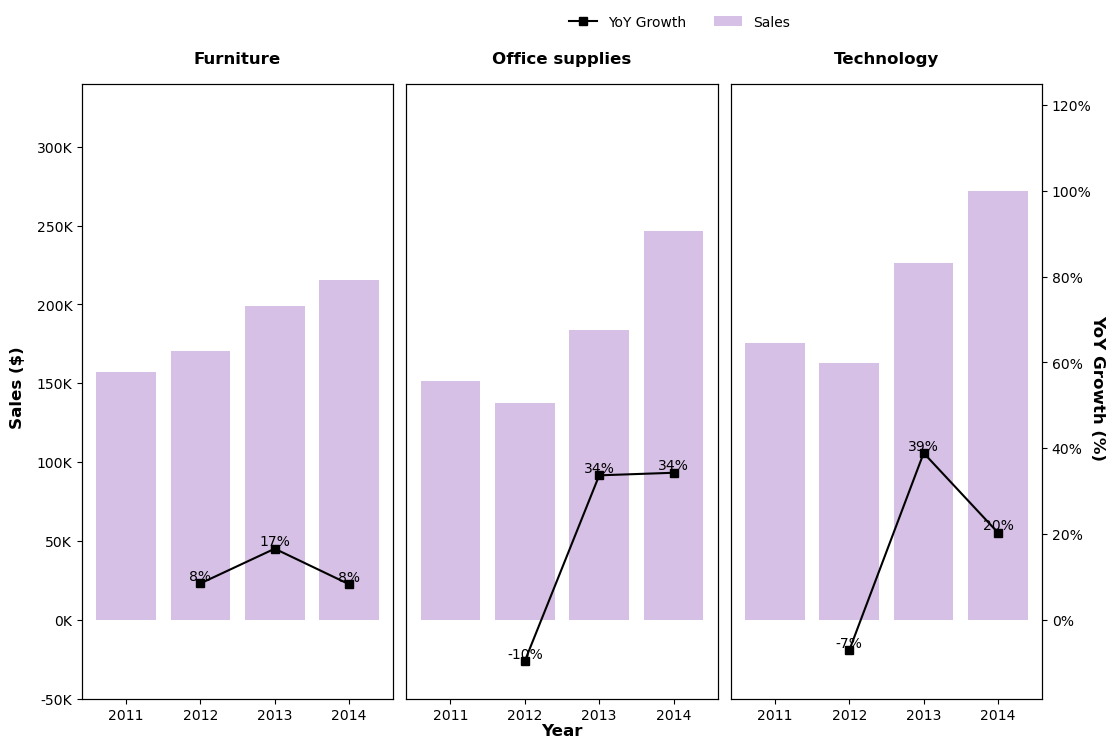

In [56]:

# -----------------------------
# Create subplots with dual axes for sales and yoy growth
# -----------------------------
categories = sp_df['category'].unique()
scale = sp_df['sales'].max()
fig, axes = plt.subplots(1, len(categories), figsize=(12,7), sharey=True)

for i, cat in enumerate(categories):
    ax = axes[i]
    sub = sp_df[sp_df['category']==cat]
    #sub = sub[np.isfinite(sub['yoy_sales_growth'])]

    # Bars for Sales
    ax.bar(sub['year'], sub['sales'], color="#813daf52", label='Sales')

    # Secondary axis for YoY Growth %
    ax2 = ax.twinx()
    ax2.plot(sub['year'], sub['yoy_sales_growth'], marker='s', color='k', label='YoY Growth')

    # Annotate percentages
    for x,y in zip(sub['year'], sub['yoy_sales_growth']):
        ax2.text(x, y, f"{y:.0%}", color="k", ha="center", va="bottom", fontsize=10)

    # Format y-axis and secondary axis
    ax.set_ylim(-50000, scale * 1.25)
    ax.set_yticklabels([f"{val/1000:.0f}K" for val in ax.get_yticks()])
    ax2.set_ylim(ax.get_ylim()[0]/scale, ax.get_ylim()[1]/scale)
    ax2.set_yticklabels([f"{v:.0%}" for v in ax2.get_yticks()])

    # show primary y-axis ticks only for the first subplots
    if i != 0:
        #ax.set_yticklabels([])
        ax.tick_params(axis='y', left=False, labelleft=False)

    # show ticks only for last subplots for secondary y-axis
    if i != len(categories) -1 :
        ax2.set_yticklabels([])
        ax2.set_yticks([])
        
    # show ticks on x-axis
    ax.set_xticks([2011, 2012, 2013, 2014])
    ax.set_xticklabels([2011, 2012, 2013, 2014])
    # title
    ax.set_title(f"{cat.capitalize()}", fontsize=12, fontweight='bold', y=1.02)
# Add dummy line for legend 
dummy_line = axes[0].plot([], [], marker='s', color='k', label="YoY Growth")

# Shared y-axis labels for both side
fig.text(0.04, 0.5, "Sales ($)", va='center', rotation=90, fontsize=12, fontweight='bold')
fig.text(0.94, 0.5, "YoY Growth (%)", va="center", rotation=270, fontsize=12, fontweight='bold')

# Shared x-axis labels
fig.text(0.5, 0.01, "Year", ha='center', va='center', fontsize=12, fontweight='bold')

# Legend
handles, legends = axes[0].get_legend_handles_labels()
fig.legend(handles, legends, loc = 'upper right', bbox_to_anchor=(0.7, 1.05),ncols=2, frameon=False)
# Legend only for dummy line 
fig.legend([dummy_line], ["YoY Growth"], loc="upper right", bbox_to_anchor=(0.7, 1),ncols=2, frameon=False)

# Add layout adjustment
plt.tight_layout()
plt.subplots_adjust(left=0.1, right=0.9)
plt.show()


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


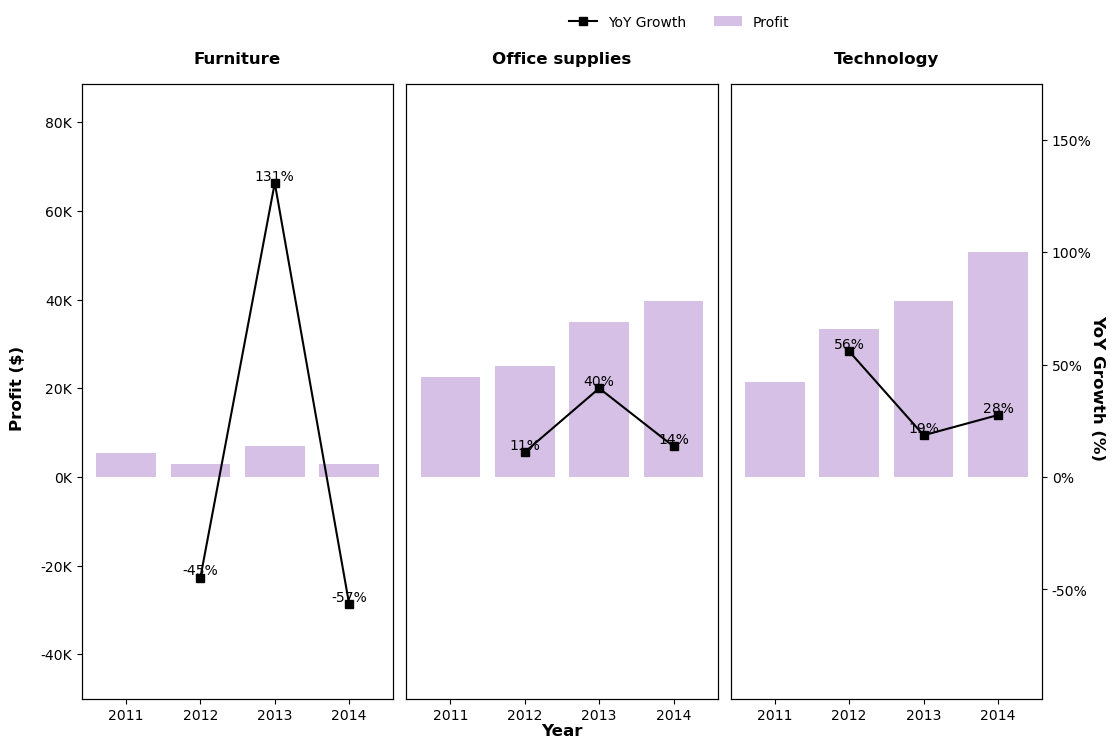

In [57]:

# -----------------------------
# Create subplots with dual axes for sales and yoy growth
# -----------------------------
categories = sp_df['category'].unique()
scale = sp_df['profit'].max()
fig, axes = plt.subplots(1, len(categories), figsize=(12,7), sharey=True)

for i, cat in enumerate(categories):
    ax = axes[i]
    sub = sp_df[sp_df['category']==cat]
    #sub = sub[np.isfinite(sub['yoy_profit_growth'])]

    # Bars for Sales
    ax.bar(sub['year'], sub['profit'] , color="#813daf52", label='Profit')

    # Secondary axis for YoY Growth %
    ax2 = ax.twinx()
    ax2.plot(sub['year'], sub['yoy_profit_growth'], marker='s', color='k', label='YoY Growth')

    # Annotate percentages
    for x,y in zip(sub['year'], sub['yoy_profit_growth']):
        ax2.text(x, y, f"{y:.0%}", color="k", ha="center", va="bottom", fontsize=10)

    # Format y-axis and secondary axis
    ax.set_ylim(-50000, scale * 1.75)
    ax.set_yticklabels([f"{val/1000:.0f}K" for val in ax.get_yticks()])
    ax2.set_ylim(ax.get_ylim()[0]/scale, ax.get_ylim()[1]/scale)
    #ax2.set_ylim(-1, 1)
    ax2.set_yticklabels([f"{v:.0%}" for v in ax2.get_yticks()])

    # show primary y-axis ticks only for the first subplots
    if i != 0:
        ax.tick_params(axis='y', left=False, labelleft=False)

    # show ticks only for last subplots for secondary y-axis
    if i != len(categories) -1 :
        ax2.set_yticklabels([])
        ax2.set_yticks([])

    # x-axis xticks
    ax.set_xticks([2011, 2012, 2013, 2014])
    ax.set_xticklabels([2011, 2012, 2013, 2014])
    
    # title
    ax.set_title(f"{cat.capitalize()}", fontsize=12, fontweight='bold', y=1.02)
# Add dummy line for legend 
dummy_line = axes[0].plot([], [], marker='s', color='k', label="YoY Growth")

# Shared y-axis labels for both side
fig.text(0.04, 0.5, "Profit ($)", va='center', rotation=90, fontsize=12, fontweight='bold')
fig.text(0.94, 0.5, "YoY Growth (%)", va="center", rotation=270, fontsize=12, fontweight='bold')

# shared x-axis
fig.text(0.5, 0.01, "Year", ha='center', va='center', fontsize=12, fontweight='bold')

# Legend
handles, legends = axes[0].get_legend_handles_labels()
fig.legend(handles, legends, loc = 'upper right', bbox_to_anchor=(0.7, 1.05),ncols=2, frameon=False)

# Legend only for dummy line 
fig.legend([dummy_line], ["YoY Growth"], loc="upper left", bbox_to_anchor=(0.7, 1.05),ncols=2, frameon=False)

# Add layout adjustment
plt.tight_layout()
plt.subplots_adjust(left=0.1, right=0.9)
plt.show()


**Observations:**

- 

**What are number of total and new customers and its YoY growth?**

In [58]:
# Compute new and total customers

cust_df = us_merged_df.copy()
# First order by each customers
first_year = (
    cust_df.groupby(['customer_id'],as_index=False)
    .agg({'year':'first'})
)

# Count new customers per year
new_df = (
    first_year.groupby(['year'])
    .agg(new_customers = ('customer_id', 'count'))
)

# Total unique customers per year
total_df = (
    cust_df.groupby(['year'], as_index=False)
    .agg(uniq_customers = ('customer_id', 'count'))
)

# join unique and new customers
customer_df = pd.merge(total_df, new_df, on = ['year'], how='left')
# Compute YoY Growth
customer_df['yoy_uniq_growth'] = customer_df['uniq_customers'].pct_change().round(2)
customer_df['yoy_new_growth'] = customer_df['new_customers'].pct_change().round(2)
# Reorder customer_df
customer_df = customer_df[['year', 'uniq_customers', 'yoy_uniq_growth', 'new_customers', 'yoy_new_growth']]


### **What is average basket size and value?**

In [59]:
# Assume Orders is a pandas DataFrame
us_merged_df['year'] = us_merged_df['order_date'].dt.year

# Step 1: group by Order ID and Year, sum Quantity and Sales
basket = (
    us_merged_df.groupby(['order_id', 'year'], as_index=False)
          .agg({'quantity': 'sum', 'sales': 'sum'})
)

# Step 2: group by Year, summarise totals
basket = (
    basket.groupby('year', as_index=False)
          .agg({
              'quantity': 'sum',
              'order_id': 'nunique',   # count distinct orders
              'sales': 'sum'
          })
          .rename(columns={'order_id': 'order_count'})
)

# Step 3: calculate Basket metrics
basket['basket_value'] = (basket['sales'] / basket['order_count']).round(2)
basket['basket_size'] = (basket['quantity'] / basket['order_count']).round(0)

# Step 4: calculate YoY Growth
basket['yoy_growth'] = basket['sales'].pct_change()

# Step 5: drop intermediate columns
basket = basket[['year', 'basket_value', 'basket_size', 'yoy_growth']]

display(basket)


,year,basket_value,basket_size,yoy_growth
0,2011,499.74,8.0,NaN
1,2012,453.31,8.0,-0.028322
2,2013,464.48,7.0,0.293160
3,2014,433.77,7.0,0.206210


## **What are total and loss orders and YoY Growth of its?**

In [60]:
# Compute total loss orders percentage in dataset
total_losses_orders = (
    us_merged_df.groupby(['order_id'], as_index=False)['profit']
    .sum()
    .assign(is_loss = lambda x: x['profit'] < 0)
    .pipe(lambda x: f"{100 * x['is_loss'].sum()/len(x):.1f}%")
)

display(f"Total Losses Orders : {total_losses_orders}")

'Total Losses Orders : 20.4%'

In [61]:
# Yearly total and loss orders in dataset
# Aggregate profit per year per order
orders_df = (
    us_merged_df.groupby(['year', 'order_id'], as_index=False)
    .agg({'profit': 'sum'})
)
# Summarise by year
orders_df = (
    orders_df.groupby(['year'], as_index=False)
    .agg(
    total_orders = ('order_id', 'nunique'),
    loss_orders = ('order_id', lambda x: (orders_df.loc[x.index, 'profit'] < 0).sum())
    )
)
# Compute YoY growth of total and loss orders
orders_df['yoy_orders'] = orders_df['total_orders'].pct_change().round(2)
orders_df['yoy_losses'] = orders_df['loss_orders'].pct_change().round(2)


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


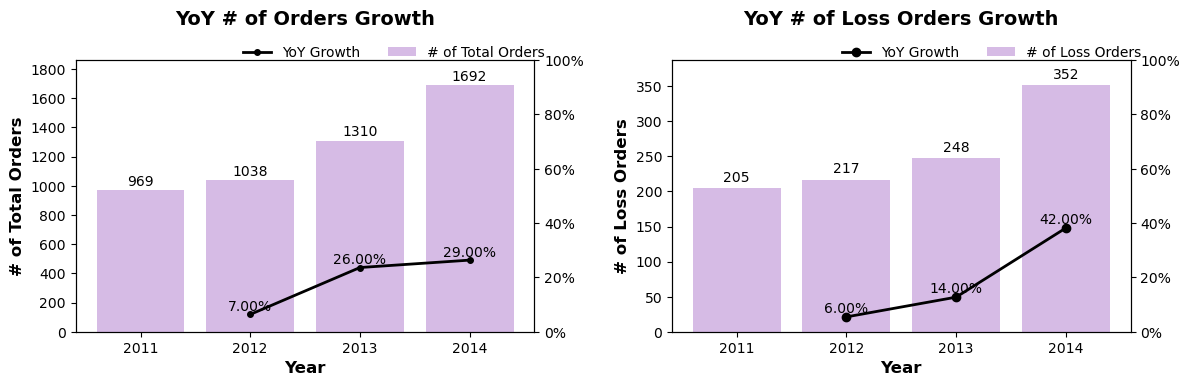

In [148]:
# Visualization of total and loss orders
scale_total = orders_df['total_orders'].max()
scale_loss = orders_df['loss_orders'].max()

# plot 1 : Total Orders
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax = ax.flatten()

# bar plot for total orders
ax[0].bar(orders_df['year'], orders_df['total_orders'], 
          color='#812daf52', label='# of Total Orders')

# Line + point plot for YoY growth
ax[0].plot(orders_df['year'], orders_df['yoy_orders'] * scale_total, 
           lw=2, ls='solid', color='k', marker='o', markersize=4, label='YoY Growth')

# Format x-axis and y-axis
ax[0].set_xticks([2011, 2012, 2013, 2014])
ax[0].set_xticklabels([2011, 2012, 2013, 2014])
ax[0].set_ylim((0, scale_total*1.1))
ax[0].set_yticks(np.arange(0, scale_total*1.1, 200))

# Add Secondary-axis for YoY 
ax1 = ax[0].twinx()
ax1.set_yticklabels([f"{val:.0%}" for val in ax1.get_yticks()])

# Add label and title
ax[0].set_ylabel("# of Total Orders", fontsize=12, fontweight='bold')
ax[0].set_xlabel('Year',fontsize=12, fontweight='bold')
ax[0].set_title('YoY # of Orders Growth', fontsize=14, fontweight='bold', y=1.10)


# Plot 2: Loss Orders
# bar plot for loss orders
ax[1].bar(orders_df['year'], orders_df['loss_orders'], 
          color='#812daf52', label = '# of Loss Orders')
# Line + point for YoY growth
ax[1].plot(orders_df['year'], orders_df['yoy_losses'] * scale_loss, 
           lw=2, ls='solid', color='k', marker='o', markersize=6, label='YoY Growth')

# Format x-axis and y-axis
ax[1].set_xticks([2011, 2012, 2013, 2014])
ax[1].set_xticklabels([2011, 2012, 2013, 2014])
ax[1].set_ylim((0, scale_loss * 1.1))
ax[1].set_yticks(np.arange(0, scale_loss * 1.1, 50))

# Add Secondary-axis for YoY 
ax2 = ax[1].twinx()
ax2.set_yticklabels([f"{val:.0%}" for val in ax2.get_yticks()])

# Add label and title
ax[1].set_ylabel("# of Loss Orders", fontsize=12, fontweight='bold')
ax[1].set_xlabel('Year',fontsize=12, fontweight='bold')
ax[1].set_title('YoY # of Loss Orders Growth', fontsize=14, fontweight='bold', y=1.10)

# Add text label for orders, loss orders and its yoy growth
for i, row in orders_df.iterrows():
    ax[0].text(
        row['year'], row['total_orders'] + 10,
        f"{row['total_orders']:.0f}", ha='center', va='bottom',
        fontsize=10, color='k'
    )
    ax[0].text(
        row['year'], row['yoy_orders'] * scale_total + 100,
        f"{row['yoy_orders']*100:.2f}%", ha='center',va ='top',
        fontsize=10, color='k' 
    )
    ax[1].text(
        row['year'], row['loss_orders'] + 5,
        f"{row['loss_orders']:.0f}", ha='center', va='bottom',
        fontsize=10, color='k'
    )
    ax[1].text(
        row['year'], row['yoy_losses'] * scale_loss + 22,
        f"{row['yoy_losses']*100:.2f}%", ha='center',va ='top',
        fontsize=10, color='k' 
    )

# Add legend
ax[0].legend(loc='upper right', bbox_to_anchor=(1.05, 1.10), ncols=2, frameon=False)
ax[1].legend(loc='upper right', bbox_to_anchor=(1.05, 1.10), ncols=2, frameon=False)

# Add layout
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

**General Metrics for 2014 Year**

In [62]:
row_sales = group_df.loc[group_df["year"] == latest_year].iloc[0]
row_cust = customer_df.loc[customer_df["year"] == latest_year].iloc[0]
row_basket = basket.loc[basket['year'] == latest_year].iloc[0]
row_orders = orders_df.loc[orders_df['year'] == latest_year].iloc[0]

# Example: dashboard DataFrame from earlier
dashboard = pd.DataFrame({
    "Year": [latest_year],
    "Gross Sales": [row_sales["sales"]],
    "YoY Sales Growth": [row_sales["yoy_sales_growth"]],
    "Gross Profit": [row_sales["profit"]],
    "YoY Profit Growth": [row_sales["yoy_profit_growth"]],
    "New Customers": [row_cust["new_customers"]],
    "YoY Growth New": [row_cust["yoy_new_growth"]],
    "Total Customers": [row_cust["uniq_customers"]],
    "YoY Growth Unique": [row_cust["yoy_uniq_growth"]],
    "Basket Value": [row_basket["basket_value"]],
    "YoY Basket Value": [row_basket["yoy_growth"]],
    "Basket Size": [row_basket["basket_size"]],
    "Total Orders": [row_orders["total_orders"]],
    "YoY Orders Growth": [row_orders["yoy_orders"]],
    "Loss Orders": [row_orders["loss_orders"]],
    "YoY Loss Orders Growth": [row_orders["yoy_losses"]],
})

# Helper function for conditional coloring
def highlight_yoy(val):
    color = "green" if val > 0 else "red"
    return f"color: {color}"

# Style the dashboard
styled_dashboard = (
    dashboard.style
    .format({
        "Gross Sales": "${:,.2f}",
        "Gross Profit": "${:,.2f}",
        "Basket Value": "${:,.2f}",
        "YoY Sales Growth": "{:.1%}",
        "YoY Profit Growth": "{:.1%}",
        "YoY Growth New": "{:.1%}",
        "YoY Growth Unique": "{:.1%}",
        "YoY Basket Value": "{:.1%}",
        "YoY Orders Growth": "{:.1%}",
        "YoY Loss Orders Growth": "{:.1%}",
    })
    .applymap(highlight_yoy, subset=[
        "YoY Sales Growth", "YoY Profit Growth", "YoY Growth New",
        "YoY Growth Unique", "YoY Basket Value",
        "YoY Orders Growth", "YoY Loss Orders Growth"
    ])
    .set_properties(**{"text-align": "center"})
    .set_caption("General Metrics for Latest Year")
    .set_table_styles(
    [{
        "selector": "caption",
        "props": [("caption-side", "top"),
                    ("text-align", "center"),
                    ("font-size", "22px"),
                    ("font-weight", "bold"),
                    ("color", "k")]
    }]
    )
)

styled_dashboard


,Year,Gross Sales,YoY Sales Growth,Gross Profit,YoY Profit Growth,New Customers,YoY Growth New,Total Customers,YoY Growth Unique,Basket Value,YoY Basket Value,Basket Size,Total Orders,YoY Orders Growth,Loss Orders,YoY Loss Orders Growth
0,2014,"$733,947.02",21.0%,"$93,507.51",14.0%,259.000000,20.0%,3319.000000,29.0%,$433.77,20.6%,7.000000,1692.000000,29.0%,352.000000,42.0%


**Which Sub-Categories are best Selling and most Profitable or Lossable?**

In [116]:
sub_category_df = (
    us_merged_df.groupby(['sub-category'], as_index=False)
    .agg({
        'sales' : 'sum',
        'profit' : 'sum',
        'quantity' : 'sum'
    })
    .sort_values(by='sales', ascending=False)
    .round(2)
    .reset_index(drop=True)
)
display(sub_category_df.head())

,sub-category,sales,profit,quantity
0,Phones,330007.05,44515.73,3289
1,Chairs,328449.10,26590.17,2356
2,Storage,223843.61,21278.83,3158
3,Tables,206965.53,-17725.48,1241
4,Binders,203412.73,30221.76,5974


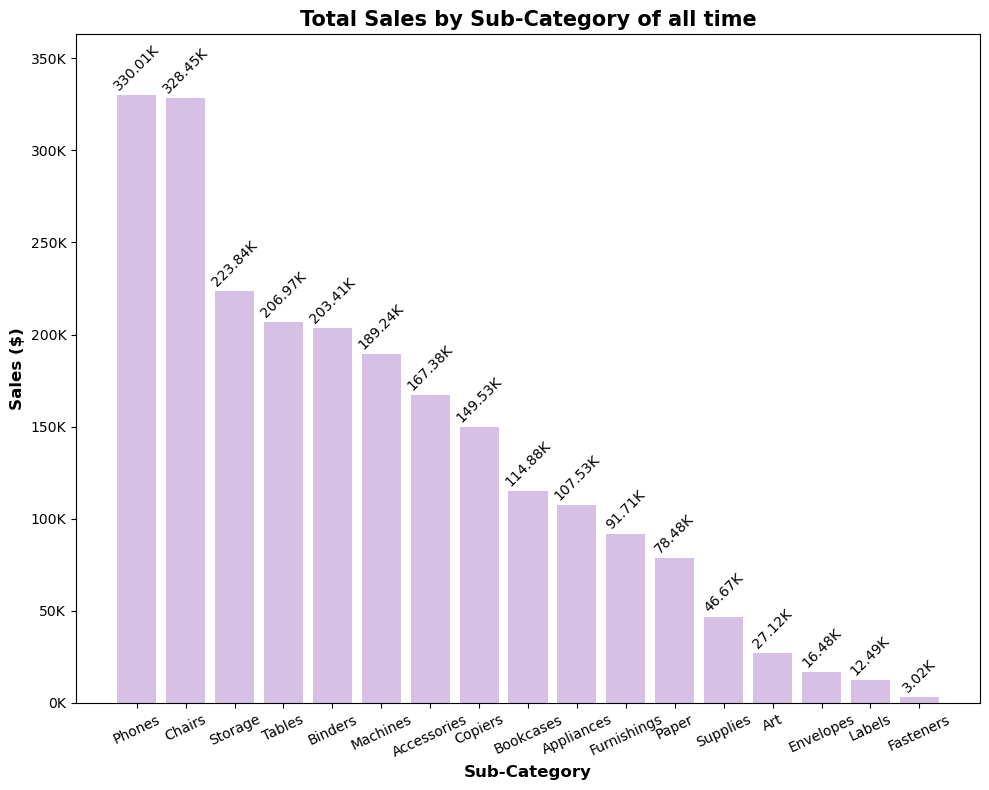

In [133]:
# Visualization of sub-category and its sales
scale = sub_category_df['sales'].max()

# Create plot
fig, ax = plt.subplots(figsize=(10,8))
ax.bar(
    sub_category_df['sub-category'], sub_category_df['sales'],
    color = "#813daf52"
)
# Add text label above bar
for i, row in sub_category_df.iterrows():
    ax.text(
        row['sub-category'], row['sales']+1000,
        f"{row['sales']/1000:.2f}K", ha='center', va='bottom',
        rotation =45,fontsize=10, color='k'
    ) 

# Format y-axis and rotate x-axis
ax.set_ylim(0, scale * 1.1)
ax.set_yticks(np.arange(0, scale * 1.1, 50000))
ax.set_yticklabels([f"{val/1000:.0f}K" for val in ax.get_yticks()])
ax.tick_params(axis='x', rotation=25)

# Add label and title
ax.set_ylabel("Sales ($)", fontsize=12, fontweight='bold')
ax.set_xlabel("Sub-Category", fontsize=12, fontweight='bold')
ax.set_title("Total Sales by Sub-Category of all time", fontsize=15, fontweight='bold')

# Add layout
plt.tight_layout()
plt.show()


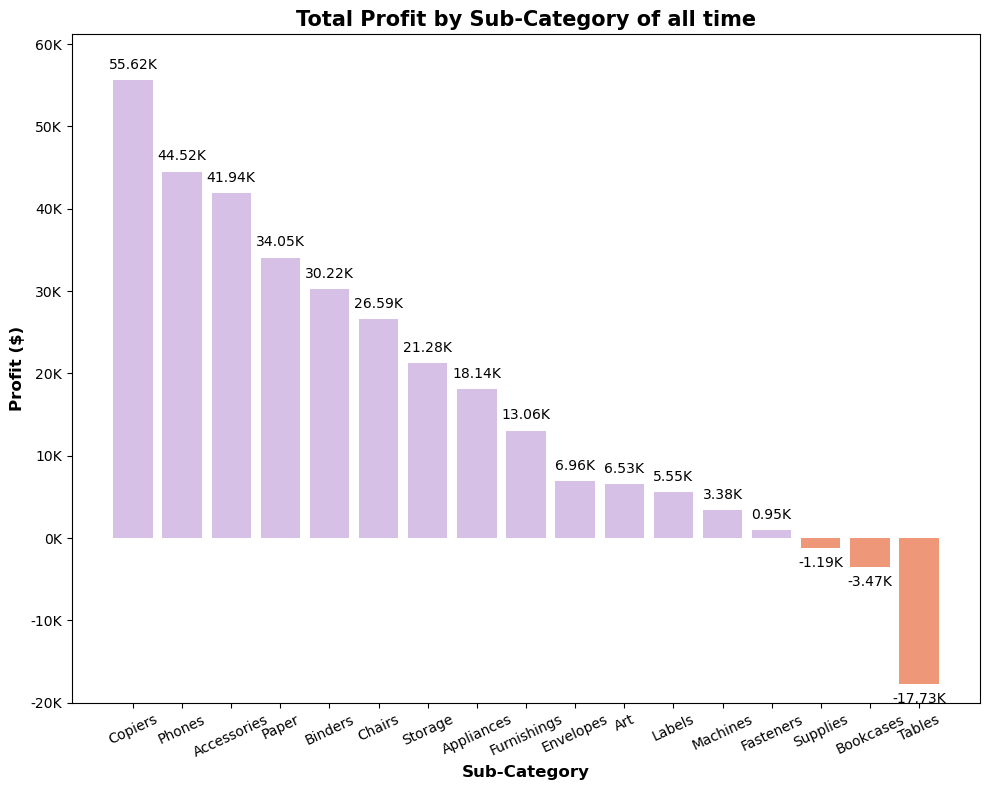

In [140]:
# Visualization of sub-category and its profit
sub_profit_df = sub_category_df.copy()
sub_profit_df = sub_profit_df.sort_values('profit', ascending=False)
scale = sub_profit_df['profit'].max()

# Assign a color category based on profit sign
sub_profit_df['profit_category'] = sub_profit_df['profit'].apply(
    lambda x: "Profit" if x > 0 else "Loss"
)

# Create plot
fig, ax = plt.subplots(figsize=(10,8))
ax.bar(
    sub_profit_df['sub-category'], sub_profit_df['profit'],
    color = sub_profit_df['profit_category'].map({"Profit":"#813daf52", "Loss":"#ee9779"})
)
# Add text label above bar
for i, row in sub_profit_df.iterrows():
    if row['profit'] >= 0:
        ypos = row['profit'] + 1000
        va = 'bottom'
    else:
        ypos = row['profit'] - 1000
        va = 'top'
    ax.text(
        row['sub-category'], ypos,
        f"{row['profit']/1000:.2f}K", ha='center', va=va,
        fontsize=10, color='k'
    ) 

# Format y-axis and rotate x-axis
ax.set_ylim(-20000, scale * 1.1)
ax.set_yticks(np.arange(-20000, scale * 1.1, 10000))
ax.set_yticklabels([f"{val/1000:.0f}K" for val in ax.get_yticks()])
ax.tick_params(axis='x', rotation=25)

# Add label and title
ax.set_ylabel("Profit ($)", fontsize=12, fontweight='bold')
ax.set_xlabel("Sub-Category", fontsize=12, fontweight='bold')
ax.set_title("Total Profit by Sub-Category of all time", fontsize=15, fontweight='bold')

# Add layout
plt.tight_layout()
plt.show()


**What its YoY Sales & Profits Growth by Sub-Category?**

In [147]:
sub_yoy_df = (
    us_merged_df[us_merged_df['year'].isin([latest_year-1, latest_year])].groupby(['year', 'sub-category'], as_index=False)
    .agg({
        'sales' : 'sum',
        'profit' : 'sum'
    })
    .round(2)
    .sort_values(['sub-category', 'year'])
    .reset_index(drop=True)
)

# Compute YoY sales and profit growth
sub_yoy_df['yoy_sales_growth'] = sub_yoy_df.groupby(['sub-category'])['sales'].pct_change().round(2)
sub_yoy_df['yoy_profit_growth'] = sub_yoy_df.groupby(['sub-category'])['profit'].pct_change().round(2)

display(sub_yoy_df.head())

,year,sub-category,sales,profit,yoy_sales_growth,yoy_profit_growth
0,2013,Accessories,41895.85,9664.29,NaN,NaN
1,2014,Accessories,59946.23,15672.36,0.43,0.62
2,2013,Appliances,26050.32,5301.34,NaN,NaN
3,2014,Appliances,42926.93,7865.27,0.65,0.48
4,2013,Art,5909.65,1408.75,NaN,NaN
